In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kendalltau, spearmanr, pearsonr
import search_results_lib as srl
import json

# CONFIG Y DATASETS

In [2]:
HIGHLIGHT_COLORS = {
    "cuestionario-cpi": "#0072B2",          # azul
    "cpi-robertuito": "#D55E00",         # naranja
    "cpi-geo": "#CC79A7", # magenta
}
tops = [10, 20, 50, 100]

ignore=['index-index', 'ordenBusquedas', 'cuestionario_ordinal', 'cuestionario_no_common']
ignore_no_common = ['index-index', 'ordenBusquedas', 'cuestionario', 'cuestionario_ordinal']

thres = {
    'cuestionario': 0.6,
    'robertuito': 0,
    'tfidf': 0.6
}

thres_no_common = {
    'cuestionario_no_common': 0.6,
    'robertuito': 0,
    'tfidf': 0.6
}

segmentation=10

In [3]:
countries = [
    "Argentina",
    "Bolivia",
    "Chile",
    "Colombia",
    "Costa Rica",
    "Cuba",
    "Ecuador",
    "El Salvador",
    "Guatemala",
    "Honduras",
    "Mexico",
    "Nicaragua",
    "Panama",
    "Paraguay",
    "Peru",
    #"Puerto Rico",
    "Dominican Republic",
    "Uruguay",
    "Venezuela",
    "Spain"
]
n_countries = len(countries)
print(n_countries)  # 20
countries.sort()
df_dict = {}
corr_dict = {}

19


In [4]:
for i, country in enumerate(countries):
    print(f"{i+1}. {country}")

1. Argentina
2. Bolivia
3. Chile
4. Colombia
5. Costa Rica
6. Cuba
7. Dominican Republic
8. Ecuador
9. El Salvador
10. Guatemala
11. Honduras
12. Mexico
13. Nicaragua
14. Panama
15. Paraguay
16. Peru
17. Spain
18. Uruguay
19. Venezuela


## Caracteristicas con buena informacion mutua

In [ ]:
def clean_features(features):
    import re
    return [
        re.sub(r"_(?:mean|std|cum|diff|delta_cum)_s\d+$", "", f)
        for f in features
    ]

fold_scores = pd.read_csv("../mi_results/crossval_data/clf_feature_scores_by_fold.csv")
feats_performance = fold_scores.groupby(['target', 'dataset', 'model', 'feature'])[['score', 'selected']].mean().reset_index().sort_values(['target', 'dataset', 'model', 'score'], ascending=[True, True, True, False])

#tfidf_feats = list(feats_performance[feats_performance['dataset'] == 'bow'][feats_performance['score'] >= 0.8]['feature'].unique())
#forms_feats = list(feats_performance[feats_performance['dataset'] == 'forms'][feats_performance['score'] >= 0.8]['feature'].unique())

tfidf_feats = list(feats_performance[feats_performance['dataset'] == 'bow'][feats_performance['selected'] >= 0.4]['feature'].unique())
forms_feats = list(feats_performance[feats_performance['dataset'] == 'forms'][feats_performance['selected'] >= 0.8]['feature'].unique())

tfidf_clean_feats = list(set(clean_features(tfidf_feats)))
forms_clean_feats = list(set(clean_features(forms_feats)))

take_from_expanded_dict = {
    'cuestionario': forms_feats,
    'robertuito': None,
    'tfidf': tfidf_feats
}

FileNotFoundError: [Errno 2] No such file or directory: 'clf_feature_scores_by_fold.csv'

In [ ]:
top = 20

suffix = '_correlation_filtered'
#suffix = ''

feats_mi = pd.read_csv("../mi_results/mutual_information_top_per_dataset" + suffix + ".csv", sep=',', header=0)
#feats_mi = pd.read_csv("../mi_results/mi_whole_dataset.csv", sep='\t', header=0)
ordered_feats_mi = feats_mi.groupby(['dataset', 'clean_feature']).mean()
ordered_feats_mi.sort_values('mutual_information', ascending=False, inplace=True)

tfidf_best_feats = ordered_feats_mi.loc['bow'].head(top).index.tolist()
forms_best_feats = ordered_feats_mi.loc['forms'].head(top).index.tolist()
robertuito_best_feats = ordered_feats_mi.loc['robertuito'].head(top).index.tolist()
'''
feats_mi = pd.read_csv("../mi_results/mutual_information_top_per_segment" + suffix + ".csv")
ordered_feats_mi = feats_mi.groupby(['dataset', 'clean_feature', 'segment']).mean()
ordered_feats_mi.sort_values(['segment', 'mutual_information'], ascending=[True, False], inplace=True)
ordered_feats_mi.reset_index(inplace=True)

ordered_feats_mi[ordered_feats_mi['dataset'] == 'tfidf'].groupby('segment').head(top)

tfidf_best_feats = ordered_feats_mi[ordered_feats_mi['dataset'] == 'tfidf']['clean_feature'].unique().tolist()
tfidf_seg_feat_dict = {
    segment: ordered_feats_mi[(ordered_feats_mi['dataset'] == 'tfidf') & (ordered_feats_mi['segment'] == segment)].head(top)['clean_feature'].tolist()
    for segment in ordered_feats_mi['segment'].unique()
}
forms_best_feats = ordered_feats_mi[ordered_feats_mi['dataset'] == 'forms']['clean_feature'].unique().tolist()
forms_seg_feat_dict = {
    segment: ordered_feats_mi[(ordered_feats_mi['dataset'] == 'forms') & (ordered_feats_mi['segment'] == segment)].head(top)['clean_feature'].tolist()
    for segment in ordered_feats_mi['segment'].unique()
}
robertuito_best_feats = ordered_feats_mi[ordered_feats_mi['dataset'] == 'robertuito']['clean_feature'].unique().tolist()
robertuito_seg_feat_dict = {
    segment: ordered_feats_mi[(ordered_feats_mi['dataset'] == 'robertuito') & (ordered_feats_mi['segment'] == segment)].head(top)['clean_feature'].tolist()
    for segment in ordered_feats_mi['segment'].unique()
}

seg_feat_dict = {
    'tfidf': tfidf_seg_feat_dict,
    'cuestionario': forms_seg_feat_dict,
    'robertuito': robertuito_seg_feat_dict
}
'''

## Datos
### Indices de corrupcion

In [4]:
path = "../datos/CPI2024-Results-and-trends.csv"
df_index = pd.read_csv(path, header=2, encoding="ISO-8859-1", sep='\t')
df_index = df_index[df_index["Country / Territory"].isin(countries)]
df_index.dropna(how="all", axis=1, inplace=True)
df_index.rename(columns={"Country / Territory": "country"}, inplace=True)
df_index.set_index('country', inplace=True)

cpi2024_sources = {
    "rank": "Rank",
    "cpi": "CPI 2024 score",
    #"gi": "S&P / Global Insights Country Risk Ratings",
    #"prs": "PRS International Country Risk Guide",
    #"vdem": "Varieties of Democracy Project",
    #"wef": "World Economic Forum EOS",
    #"wjp": "World Justice Project Rule of Law cpi",
    #"bti": "Bertelsmann Foundation Transformation cpi",
    #"eiu": "Economist Intelligence Unit Country Ratings"
}
df_index.rename(columns=dict(zip(cpi2024_sources.values(), cpi2024_sources.keys())), inplace=True)

df_index.drop(columns=[i for i in df_index.columns if i not in cpi2024_sources.keys()], inplace=True)
df_index = df_index.reindex(countries)
df_index.dropna(how='all', inplace=True)
df_index.sort_index(inplace=True)
df_dict["cpi"] = df_index
df_index

,cpi,rank
country,,
Argentina,37,99
Bolivia,28,133
Chile,63,32
Colombia,39,92
Costa Rica,58,42
Cuba,41,82
Dominican Republic,36,104
Ecuador,32,121
El Salvador,30,130


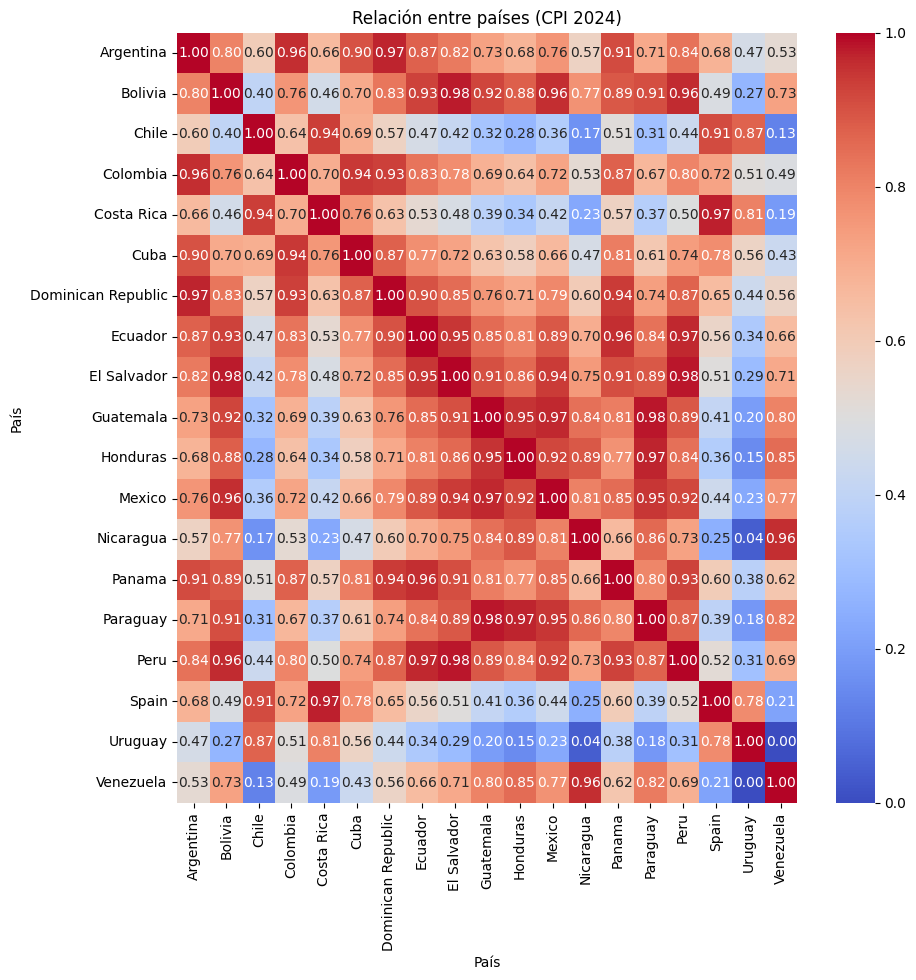

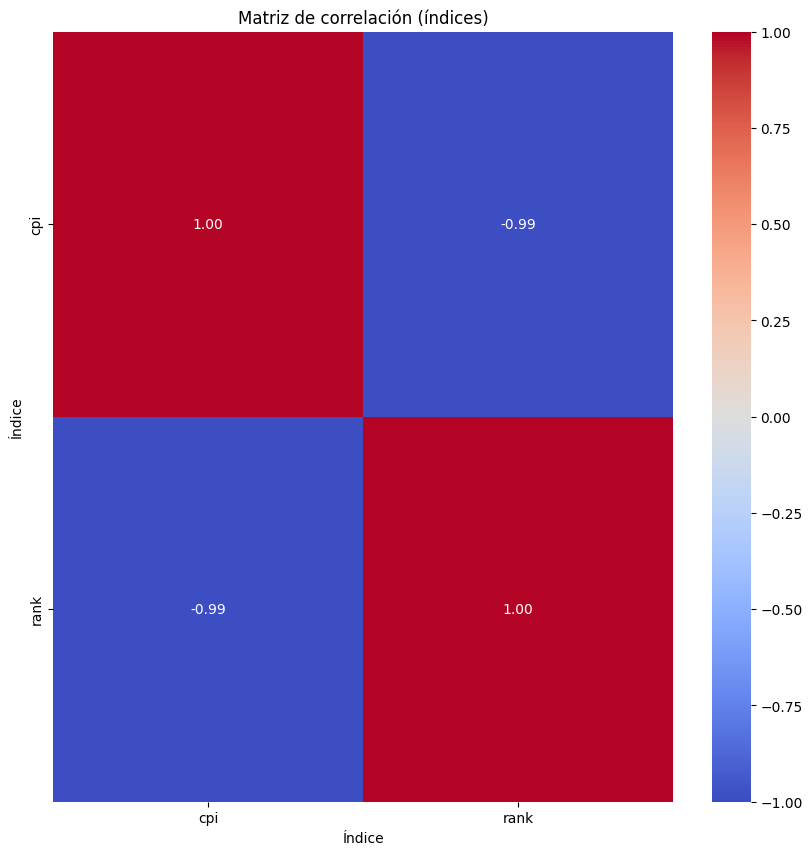

In [5]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform

X = df_index.copy()

# Asegura numérico y limpia inf
X = X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

# Imputa NaNs con mediana de cada columna
X_imp = X.fillna(X.median(numeric_only=True))

cpi = squareform(pdist(X_imp.values, metric="euclidean"))
cpi = 1 - (cpi / np.max(cpi))  # Normaliza a [0, 1] y convierte a similitud
corr_dict["cpi"] = pd.DataFrame(cpi, index=X_imp.index, columns=X_imp.index)

plt.figure(figsize=(10,10))
sns.heatmap(corr_dict['cpi'], annot=True, cmap="coolwarm", vmin=0, vmax=1, fmt=".2f")
#sns.heatmap(np.abs(index_corr), annot=True, cmap="coolwarm", vmin=0, vmax=1, fmt=".1f")
plt.title("Relación entre países (CPI 2024)")
plt.xlabel("País")
plt.ylabel("País")
plt.show()

corr_dict['index-index'] = df_index.corr()

plt.figure(figsize=(10,10))
#sns.heatmap(index_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
sns.heatmap(corr_dict['index-index'], annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de correlación (índices)")
plt.xlabel("Índice")
plt.ylabel("Índice")
plt.show()

### Rankings resultados de busqueda

In [6]:
Nombre_Archivo = f"../datos/resultados_corrupcion.json"

with open(Nombre_Archivo, "r") as file:
    resultados = json.load(file)
for i in range(len(resultados)):
    if resultados[i]['country'] == 'Puerto Rico':
        resultados.pop(i)
        break
resultados.sort(key=lambda x: x['country'])

# Leer el archivo JSON guardado
Nombre_Archivo = f"../datos/res_unicos_corrupcion.json"

with open(Nombre_Archivo, "r") as file:
    all_hrefs = json.load(file)

max_len = max([len(r['search_results']['results']) for r in resultados])
rankings = {}
for r in resultados:
    pages = [all_hrefs.index(res['href']) for res in r['search_results']['results']]
    if len(pages) < max_len:
        diff = max_len - len(pages)
        pages += [np.nan] * diff
    rankings[r['country']] = pages
df_rankings = pd.DataFrame(rankings).T
df_rankings.sort_index(inplace=True)
df_dict["rankings"] = df_rankings
df_rankings

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
Argentina,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,90.0,91.0,92.0,93.0,94.0,95.0,96.0,97.0,98.0,99.0
Bolivia,0.0,1.0,3.0,5.0,2.0,4.0,28.0,100.0,55.0,101.0,...,153.0,154.0,155.0,97.0,156.0,157.0,65.0,158.0,59.0,NaN
Chile,1.0,4.0,159.0,160.0,3.0,2.0,5.0,33.0,161.0,144.0,...,51.0,208.0,116.0,209.0,125.0,210.0,211.0,212.0,139.0,82.0
Colombia,0.0,1.0,3.0,2.0,4.0,5.0,28.0,8.0,119.0,43.0,...,266.0,75.0,144.0,132.0,124.0,146.0,267.0,131.0,86.0,268.0
Costa Rica,1.0,3.0,2.0,4.0,5.0,158.0,28.0,269.0,270.0,271.0,...,137.0,59.0,82.0,125.0,155.0,298.0,299.0,300.0,NaN,NaN
Cuba,0.0,1.0,2.0,3.0,4.0,5.0,28.0,55.0,43.0,8.0,...,315.0,30.0,299.0,141.0,153.0,316.0,32.0,101.0,NaN,NaN
Dominican Republic,0.0,1.0,3.0,2.0,4.0,5.0,106.0,120.0,28.0,527.0,...,300.0,475.0,79.0,361.0,127.0,344.0,143.0,155.0,31.0,312.0
Ecuador,1.0,3.0,159.0,5.0,317.0,2.0,4.0,63.0,318.0,319.0,...,68.0,136.0,353.0,96.0,138.0,58.0,153.0,NaN,NaN,NaN
El Salvador,0.0,1.0,2.0,3.0,4.0,5.0,28.0,354.0,55.0,43.0,...,143.0,158.0,138.0,140.0,209.0,53.0,314.0,77.0,362.0,203.0
Guatemala,0.0,1.0,2.0,3.0,5.0,4.0,49.0,116.0,28.0,294.0,...,285.0,382.0,312.0,146.0,51.0,131.0,383.0,166.0,360.0,384.0


### Evaluaciones de cuestionario

In [7]:
df_responses = pd.read_csv("../datos/responses_llama.csv", sep='\t', header=0)

multi_choice = ['proposito',
                'informacion_presentada',
                'consecuencias',
                'intencion',
                'localidad_problema',
                'involucrados',
                'emociones']

possible_answers = {"tipo_entidad": ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i'],
                    "origen_entidad": ['a', 'b'],
                    "vision": ['a', 'b', 'c', 'd'],
                    'que_muestra': ['a', 'b', 'c', 'd'],
                    'formalidad': ['a', 'b'],
                    'nivel_educacion': ['a', 'b'],
                    'tono': ['a', 'b'],
                    "proposito": ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i'],
                    "informacion_presentada": ['a', 'b', 'c'],
                    "consecuencias": ['a', 'b', 'c', 'd'],
                    "intencion": ['a', 'b', 'c', 'd', 'e', 'f'],
                    "localidad_problema": ['a', 'b', 'c'],
                    "involucrados": ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h'],
                    "emociones": ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
                    }
single_questions = [q for q in possible_answers if q not in multi_choice]

# humano < 75% precision llama < 0.6
#bad_questions = ['proposito__d', 'tono', 'intencion__c', 'que_muestra', 'proposito__g', 'consecuencias__c', 'proposito__b', 'emociones__h', 'formalidad', 'localidad_problema__a']
bad_questions = ['proposito__d', 'tono', 'que_muestra', 'proposito__g', 'proposito__b', 'emociones__h', 'formalidad']
# humano < 75% precision llama <= 0.6
#bad_questions = ['proposito__d', 'tono', 'intencion__c', 'que_muestra', 'proposito__g', 'consecuencias__c', 'proposito__b', 'involucrados__f', 'origen_entidad', 'intencion__b', 'emociones__h', 'vision', 'intencion__a', 'formalidad', 'involucrados__b', 'tipo_entidad', 'localidad_problema__a', 'localidad_problema__b']
#bad_questions.remove('emociones__h') # se elimina emocion neutral
for q in bad_questions:
    if "__" not in q:
        for i in possible_answers.get(q, []):
            bad_questions.append(f"{q}__{i}")
bad_questions = [bad for bad in bad_questions if "__" in bad]

df_pag_info = srl.analyze_pages(df_responses, multi_choice, possible_answers)
df_pag_info = df_pag_info.drop(columns=bad_questions)
df_pag_info.index.name = 'page_id'
one_hot_cols = [col for col in df_pag_info.columns if df_pag_info[col].isin([0, 1]).all()]
df_pag_info_ordinal = srl.analyze_pages(df_responses, multi_choice, possible_answers, ordinal=True)
df_pag_info_ordinal = df_pag_info_ordinal.drop(columns=bad_questions)
#df_dict["cuestionario"] = df_pag_info[forms_best_feats]
df_dict["cuestionario"] = df_pag_info#[forms_clean_feats]
#df_dict["cuestionario_ordinal"] = df_pag_info_ordinal

df_dict['cuestionario']

,nivel_educacion__a,nivel_educacion__b,origen_entidad__a,origen_entidad__b,tipo_entidad__a,tipo_entidad__b,tipo_entidad__c,tipo_entidad__d,tipo_entidad__e,tipo_entidad__f,...,involucrados__f,involucrados__g,involucrados__h,emociones__a,emociones__b,emociones__c,emociones__d,emociones__e,emociones__f,emociones__g
page_id,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,1,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
1,0,1,0,1,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.333333,0.000000,0.000000
2,0,1,0,1,0,0,0,0,0,0,...,0.666667,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.333333,0.000000
3,0,1,0,1,0,0,1,0,0,0,...,0.333333,0.000000,0.333333,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
4,0,1,0,1,0,0,0,0,0,0,...,1.000000,0.333333,0.000000,0.0,0.0,0.0,0.333333,0.333333,0.333333,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,0,1,1,0,0,0,0,1,0,0,...,0.333333,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.333333,0.000000,0.333333
593,0,1,0,1,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.333333,0.333333
594,0,1,1,0,0,1,0,0,0,0,...,0.666667,0.000000,0.333333,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.666667


### Robertuito

In [8]:
bad_labels = ['emotion__others', 'sentiment__NEU', 'irony__not ironic']
df_robertuito = pd.read_csv("../datos/robertuito_all_results.csv").drop(columns=bad_labels)
df_robertuito.set_index('pagina', inplace=True)
df_robertuito.index.name = 'page_id'
df_dict["robertuito"] = df_robertuito#[robertuito_best_feats]
df_robertuito

,emotion__joy,emotion__sadness,emotion__anger,emotion__fear,emotion__surprise,emotion__disgust,sentiment__NEG,sentiment__POS,hate__speech__hateful,hate__speech__targeted,hate__speech__aggressive,irony__ironic
page_id,,,,,,,,,,,,
12,0.00,0.02,0.75,0.0,0.01,0.09,0.84,0.01,0.04,0.01,0.02,0.00
571,0.00,0.00,0.00,0.0,0.00,0.00,0.09,0.05,0.03,0.01,0.02,0.13
200,0.00,0.00,0.00,0.0,0.00,0.00,0.07,0.12,0.02,0.01,0.01,0.01
394,0.00,0.00,0.00,0.0,0.00,0.00,0.07,0.15,0.02,0.01,0.02,0.01
397,0.00,0.01,0.04,0.0,0.00,0.00,0.65,0.03,0.03,0.01,0.03,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.01,0.00,0.00,0.0,0.00,0.00,0.10,0.14,0.02,0.01,0.01,0.08
9,0.00,0.00,0.00,0.0,0.00,0.00,0.17,0.09,0.02,0.00,0.01,0.00
575,0.00,0.01,0.64,0.0,0.00,0.05,0.32,0.03,0.02,0.00,0.02,0.01


### Word2Vec

In [21]:
df_dict['tfidf'] = pd.read_csv('../datos/matriz_tfidf.csv', index_col=0)
df_dict['tfidf'].index.name = 'page_id'

feats_w2v = pd.read_csv('../datos/feats_w2v.txt', header=0, sep='\t')
feats = 'sin_corrupcion'
df_dict['w2v'] = df_dict['tfidf'][feats_w2v[feats]]

del feats_w2v, feats

df_dict['w2v']

,delincuencia,inestabilidad politica,represion,criminalidad,burocracia,lucha fraude,ineficiencia,ilegalidad,ineficacia,violencia,...,democracia derecho,delitos comprendidos,incertidumbre,honradez,desigualdades,instituciones financieras,delito,delito bienes,gobierno federal,materia
page_id,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0000,0.00000,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.023586
1,0.004044,0.000000,0.000000,0.0,0.000000,0.000000,0.0000,0.00000,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.011090,0.0,0.0,0.008531
2,0.009581,0.028119,0.038888,0.0,0.010267,0.014227,0.0118,0.00000,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.006569,0.0,0.0,0.006737
3,0.290319,0.000000,0.000000,0.0,0.000000,0.000000,0.0000,0.00000,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.022116,0.0,0.0,0.000000
4,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0000,0.00000,0.0,0.000000,...,0.0,0.0,0.0,0.092929,0.0,0.0,0.023333,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0000,0.00000,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
593,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0000,0.00000,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.070338,0.0,0.0,0.000000
594,0.000000,0.000000,0.000000,0.0,0.000000,0.054912,0.0000,0.00000,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000


# Prediccion

## Construccion de dataset

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, RepeatedKFold, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

<Axes: xlabel='cpi', ylabel='Count'>

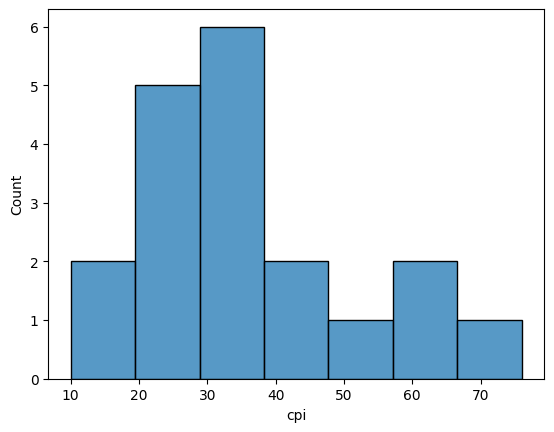

In [11]:
import seaborn as sns
sns.histplot(df_dict['cpi']['cpi'])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [Text(0, 0, 'Venezuela'),
  Text(1, 0, 'Nicaragua'),
  Text(2, 0, 'Honduras'),
  Text(3, 0, 'Paraguay'),
  Text(4, 0, 'Guatemala'),
  Text(5, 0, 'Mexico'),
  Text(6, 0, 'Bolivia'),
  Text(7, 0, 'El Salvador'),
  Text(8, 0, 'Peru'),
  Text(9, 0, 'Ecuador'),
  Text(10, 0, 'Panama'),
  Text(11, 0, 'Dominican Republic'),
  Text(12, 0, 'Argentina'),
  Text(13, 0, 'Colombia'),
  Text(14, 0, 'Cuba'),
  Text(15, 0, 'Spain'),
  Text(16, 0, 'Costa Rica'),
  Text(17, 0, 'Chile'),
  Text(18, 0, 'Uruguay')])

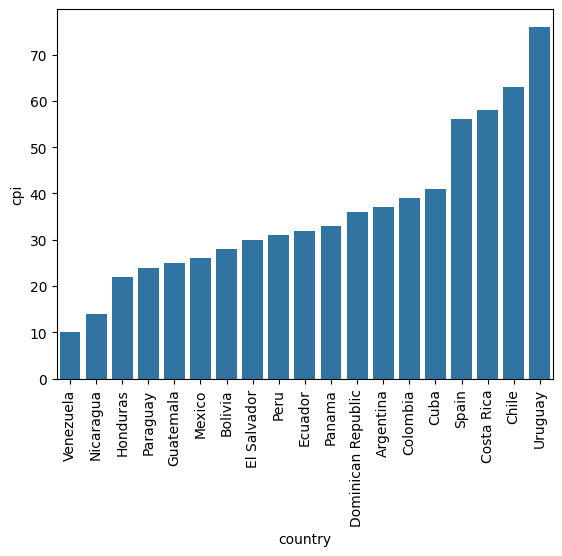

In [12]:
sns.barplot(x=df_dict['cpi'].index, y=df_dict['cpi']['cpi'], order=df_dict['cpi'].sort_values('cpi').index)
plt.xticks(rotation=90)

<Axes: xlabel='2-clases', ylabel='cpi'>

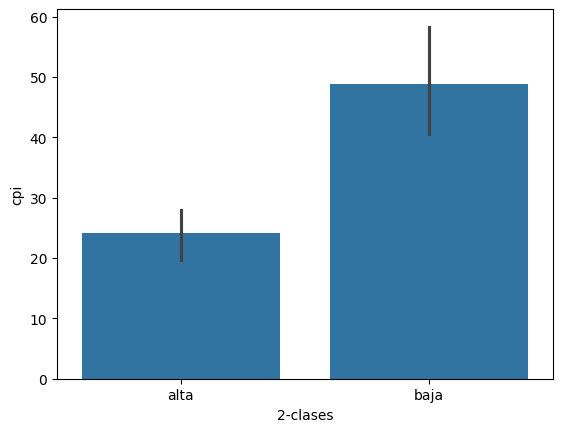

In [13]:
df_dict['regresion'] = df_dict['cpi'][['cpi']]
dict_class_names = {
    2: ['alta', 'baja'],
    3: ['alta', 'media', 'baja'],
    #4: ['muy alta', 'alta', 'baja', 'muy baja']
}
for i in [2, 3]:#, 4]:
    df_dict['regresion'][f'{i}-clases'] = pd.qcut(df_dict['cpi']['cpi'], q=i, labels=dict_class_names[i])
sns.barplot(x=df_dict['regresion']['2-clases'], y=df_dict['cpi']['cpi'], order=dict_class_names[2])

In [14]:
df_dict['regresion']

,cpi,2-clases,3-clases
country,,,
Argentina,37,baja,media
Bolivia,28,alta,alta
Chile,63,baja,baja
Colombia,39,baja,baja
Costa Rica,58,baja,baja
Cuba,41,baja,baja
Dominican Republic,36,baja,media
Ecuador,32,alta,media
El Salvador,30,alta,media


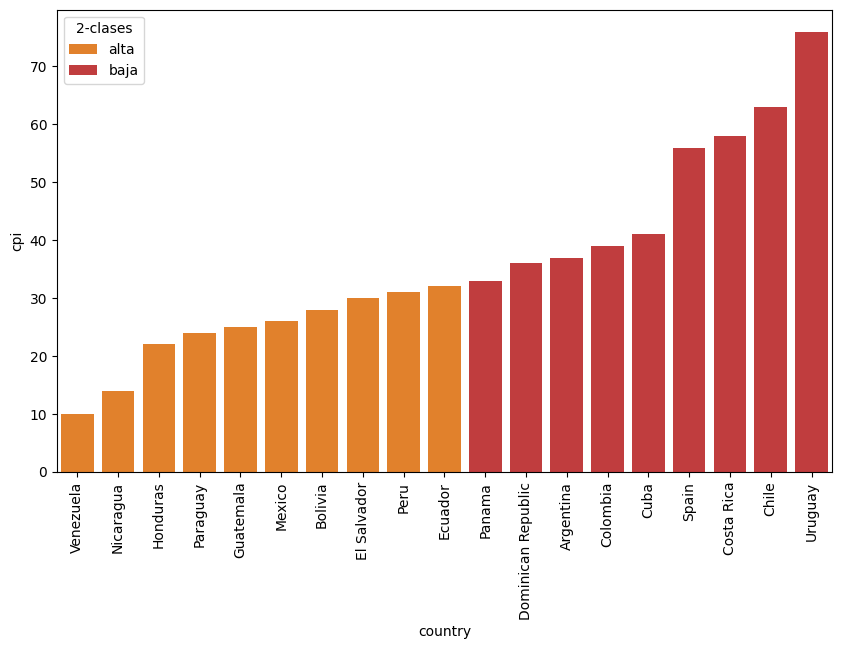

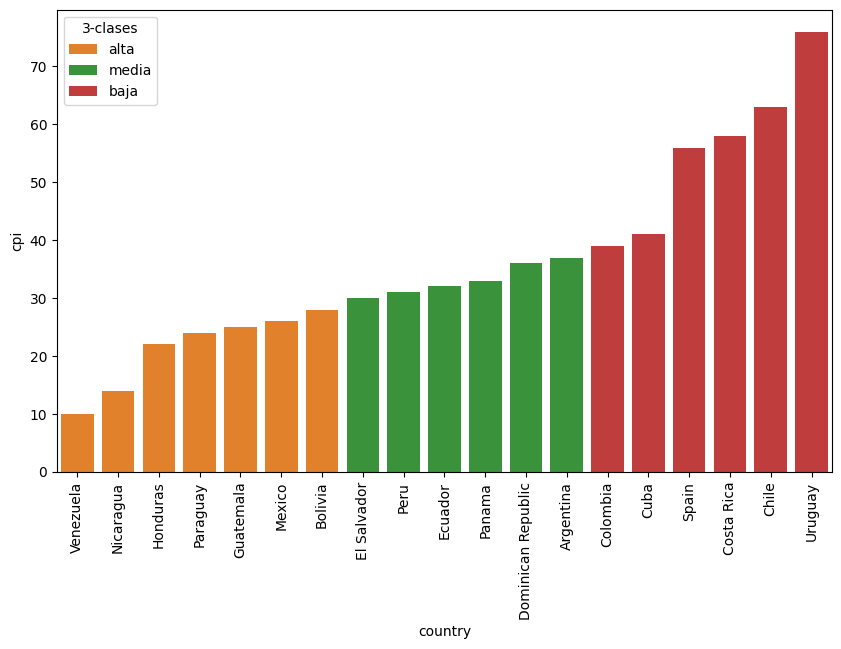

In [15]:
COLOR_MAP_TEXT = {
    'muy alta': '#1f77b4',   # Azul
    'alta':     '#ff7f0e',   # Naranja
    'media':    '#2ca02c',   # Verde
    'baja':     '#d62728',   # Rojo
    'muy baja': '#9467bd'    # Morado
}

df = df_dict['regresion'].sort_values('cpi')

for clases in df.columns[1:]:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df,
        x=df.index,
        y='cpi',
        hue=clases,
        palette=COLOR_MAP_TEXT, dodge=False
    )
    plt.xticks(rotation=90)

In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_score, cross_validate
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import make_scorer, accuracy_score

In [22]:
X_dict = {}
wide_dict = {}

_, wide_dict['cuestionario'] = srl.compute_rank_feature_distance(
    df_dict['rankings'],
    df_dict['cuestionario'],
    expanded=True,
    by='correlation',
    threshold=0.6,
    compare_to=df_dict['cpi'][['cpi']],
    min_features_ratio=3,
)
X_dict['cuestionario'] = wide_dict['cuestionario'].values

_, wide_dict['robertuito'] = srl.compute_rank_feature_distance(
    df_dict['rankings'],
    df_dict['robertuito'],
    expanded=True,
    by='correlation',
    threshold=0.6,
    compare_to=df_dict['cpi'][['cpi']],
    min_features_ratio=3,
)
X_dict['robertuito'] = wide_dict['robertuito'].values

_, wide_dict['w2v'] = srl.compute_rank_feature_distance(
    df_dict['rankings'],
    df_dict['w2v'],
    expanded=True,
    by='correlation',
    threshold=0.6,
    compare_to=df_dict['cpi'][['cpi']],
    min_features_ratio=3,
)
X_dict['w2v'] = wide_dict['w2v'].values

_, wide_dict['tfidf'] = srl.compute_rank_feature_distance(
    df_dict['rankings'],
    df_dict['tfidf'],
    expanded=True,
    by='correlation',
    threshold=0.6,
    compare_to=df_dict['cpi'][['cpi']],
    min_features_ratio=3,
)
X_dict['tfidf'] = wide_dict['tfidf'].values

for key in X_dict:
    X_dict[key] = StandardScaler().fit_transform(X_dict[key])

for dataset, X in X_dict.items():
    print(f"{dataset}: {X.shape}")

/home/juancho/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/home/juancho/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Advertencia: El threshold 0.6 filtró todas las características. Ajustando a 0.5549 para mantener 3 características.


/home/juancho/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/home/juancho/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


cuestionario: (19, 30)
robertuito: (19, 3)
w2v: (19, 201)
tfidf: (19, 3910)


## Clasificacion

### Leave One Out

#### Hiperparametros y seleccion de caracteristicas

In [23]:
resultados = []
sel_feats = {}
k_vals = [2, 5, 10, 15, 20, 30]

modelos = {
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(
            max_iter=1000,
            random_state=42
        ),
    'SVC': SVC(random_state=42)
}

pipelines = {
    'Naive Bayes': Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf', GaussianNB())
    ]),
    'Logistic Regression': Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'SVC': Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf', SVC(random_state=42))
    ])
}

param_grid_dict = {
    'Naive Bayes': {
        'selector__k': k_vals
    },
    'Logistic Regression': {
        'selector__k': k_vals,
        'clf__C': [0.001, 0.01, 0.1, 0.5, 1.0, 10.0],
        'clf__penalty': ['l1'],
        'clf__solver': ['liblinear']
    },
    'SVC': {
        'selector__k': k_vals,
        'clf__C': [0.001, 0.01, 0.1, 0.5, 1.0, 10.0],
        'clf__kernel': ['linear']
    }
}

loo = LeaveOneOut()

resultados = []
best_models = {}
selected_feats = {}

for classes in df_dict['regresion'].columns[1:]:
    y = df_dict['regresion'][classes].values
    for dataset_name, X in X_dict.items():
        print(f"Dataset: {dataset_name}")
        for model_name in pipelines.keys():
            print(f"\tModelo: {model_name}")

            grid = GridSearchCV(
                estimator=pipelines[model_name],
                param_grid=param_grid_dict[model_name],
                scoring='accuracy',
                cv=loo,
                n_jobs=-1,
                verbose=1
            )
            grid.fit(X, y)
            print(f"\t\tMejores parámetros: {grid.best_params_}")
            print(f"\t\tMejor score: {grid.best_score_:.4f}")

            key = f"{dataset_name}_{model_name}"
            best_models[key] = grid.best_estimator_

            selector = grid.best_estimator_.named_steps['selector']
            selected_indices = selector.get_support(indices=True)
            feats_names = wide_dict[dataset_name].columns[selected_indices]
            selected_feats[key] = {
                'indices': selected_indices.tolist(),
                'features': feats_names.tolist(),
                'scores': selector.scores_[selected_indices].tolist(),
                'p-values': selector.pvalues_[selected_indices].tolist(),
                'n_feats': len(selected_indices)

            }
            print(f"\t\tCaracteristicas seleccionadas: {feats_names.tolist()}")

            resultados.append({
                'target': classes,
                'model': model_name,
                'dataset': dataset_name,
                'best_params': grid.best_params_,
                'best_score': grid.best_score_,
                'n_feats': selected_feats[key]['n_feats'],
                'selected_features': selected_feats[key]
            })

df_resultados = pd.DataFrame(resultados)
print("\n=== Resultados Resumidos ===")
print(df_resultados)

# Crear DataFrame detallado de características
df_caracteristicas = []
for key, info in selected_feats.items():
    if info['scores'] is not None:
        for idx, name, score, pval in zip(info['indices'], info['features'], 
                                         info['scores'], info['p-values']):
            df_caracteristicas.append({
                'configuracion': key,
                'modelo': key.split('_')[0],
                'dataset': '_'.join(key.split('_')[1:]),
                'indice': idx,
                'nombre': name,
                'f_score': score,
                'p_value': pval
            })

df_caracteristicas = pd.DataFrame(df_caracteristicas)
print("\n=== Características Seleccionadas ===")
print(df_caracteristicas)

# Guardar
df_resultados.to_csv('resultados_gridsearch_con_seleccion_loo.csv', index=False)
df_caracteristicas.to_csv('caracteristicas_seleccionadas_detalle_loo.csv', index=False)

Dataset: cuestionario
	Modelo: Naive Bayes
Fitting 19 folds for each of 6 candidates, totalling 114 fits
		Mejores parámetros: {'selector__k': 5}
		Mejor score: 0.8947
		Caracteristicas seleccionadas: ['emociones__e_delta_cum_s6', 'involucrados__b_mean_s6', 'consecuencias__b_delta_cum_s10', 'consecuencias__b_mean_s10', 'emociones__e_mean_s6']
	Modelo: Logistic Regression
Fitting 19 folds for each of 36 candidates, totalling 684 fits
		Mejores parámetros: {'clf__C': 0.5, 'clf__penalty': 'l1', 'clf__solver': 'liblinear', 'selector__k': 5}
		Mejor score: 0.8421
		Caracteristicas seleccionadas: ['emociones__e_delta_cum_s6', 'involucrados__b_mean_s6', 'consecuencias__b_delta_cum_s10', 'consecuencias__b_mean_s10', 'emociones__e_mean_s6']
	Modelo: SVC
Fitting 19 folds for each of 36 candidates, totalling 684 fits
		Mejores parámetros: {'clf__C': 0.1, 'clf__kernel': 'linear', 'selector__k': 5}
		Mejor score: 0.8947
		Caracteristicas seleccionadas: ['emociones__e_delta_cum_s6', 'involucrados__b

/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
95 fits failed out of a total of 114.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
19 fits failed with the following error:
Traceback (most recent call last):
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/pipeline.py", line 423, in fit
    Xt = self._fit(X, y, **fit_params_steps)
  Fil

		Mejores parámetros: {'clf__C': 0.5, 'clf__penalty': 'l1', 'clf__solver': 'liblinear', 'selector__k': 2}
		Mejor score: 0.8947
		Caracteristicas seleccionadas: ['emotion__surprise_diff_s5', 'sentiment__POS_mean_s9']
	Modelo: SVC
Fitting 19 folds for each of 36 candidates, totalling 684 fits


/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
570 fits failed out of a total of 684.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
114 fits failed with the following error:
Traceback (most recent call last):
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/pipeline.py", line 423, in fit
    Xt = self._fit(X, y, **fit_params_steps)
  F

		Mejores parámetros: {'clf__C': 10.0, 'clf__kernel': 'linear', 'selector__k': 2}
		Mejor score: 0.8947
		Caracteristicas seleccionadas: ['emotion__surprise_diff_s5', 'sentiment__POS_mean_s9']
Dataset: w2v
	Modelo: Naive Bayes
Fitting 19 folds for each of 6 candidates, totalling 114 fits
		Mejores parámetros: {'selector__k': 2}
		Mejor score: 0.9474
		Caracteristicas seleccionadas: ['etica gubernamental_delta_cum_s9', 'etica gubernamental_cum_s9']
	Modelo: Logistic Regression
Fitting 19 folds for each of 36 candidates, totalling 684 fits
		Mejores parámetros: {'clf__C': 0.5, 'clf__penalty': 'l1', 'clf__solver': 'liblinear', 'selector__k': 10}
		Mejor score: 0.9474
		Caracteristicas seleccionadas: ['etica gubernamental_delta_cum_s9', 'etica gubernamental_cum_s8', 'etica gubernamental_cum_s9', 'politicos_diff_s8', 'imperio ley_cum_s7', 'imperio ley_cum_s8', 'etica gubernamental_cum_s10', 'social politico_delta_cum_s5', 'corruptos_cum_s3', 'suprema justicia_diff_s6']
	Modelo: SVC
Fitting 

/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
95 fits failed out of a total of 114.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
19 fits failed with the following error:
Traceback (most recent call last):
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/pipeline.py", line 423, in fit
    Xt = self._fit(X, y, **fit_params_steps)
  Fil

		Mejores parámetros: {'clf__C': 0.001, 'clf__penalty': 'l1', 'clf__solver': 'liblinear', 'selector__k': 2}
		Mejor score: 0.3684
		Caracteristicas seleccionadas: ['emotion__surprise_diff_s5', 'sentiment__POS_mean_s9']
	Modelo: SVC
Fitting 19 folds for each of 36 candidates, totalling 684 fits


/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
570 fits failed out of a total of 684.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
114 fits failed with the following error:
Traceback (most recent call last):
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/pipeline.py", line 423, in fit
    Xt = self._fit(X, y, **fit_params_steps)
  F

		Mejores parámetros: {'clf__C': 0.1, 'clf__kernel': 'linear', 'selector__k': 2}
		Mejor score: 0.2632
		Caracteristicas seleccionadas: ['emotion__surprise_diff_s5', 'sentiment__POS_mean_s9']
Dataset: w2v
	Modelo: Naive Bayes
Fitting 19 folds for each of 6 candidates, totalling 114 fits
		Mejores parámetros: {'selector__k': 5}
		Mejor score: 0.6316
		Caracteristicas seleccionadas: ['etica gubernamental_delta_cum_s9', 'etica gubernamental_cum_s8', 'etica gubernamental_cum_s9', 'modernidad_std_s10', 'prosperidad_diff_s8']
	Modelo: Logistic Regression
Fitting 19 folds for each of 36 candidates, totalling 684 fits
		Mejores parámetros: {'clf__C': 10.0, 'clf__penalty': 'l1', 'clf__solver': 'liblinear', 'selector__k': 10}
		Mejor score: 0.6316
		Caracteristicas seleccionadas: ['etica gubernamental_delta_cum_s9', 'etica gubernamental_cum_s8', 'etica gubernamental_cum_s9', 'funcionarios publicos_mean_s1', 'funcionarios publicos_cum_s1', 'modernidad_std_s10', 'gestion publica_mean_s4', 'abuso a

In [24]:
#df_resultados.sort_values(by=['model', 'dataset', 'best_score'], ascending=[True, True, False], inplace=True)
df_resultados.sort_values('best_score', ascending=False, inplace=True)
df_resultados

,target,model,dataset,best_params,best_score,n_feats,selected_features
6,2-clases,Naive Bayes,w2v,{'selector__k': 2},0.947368,2,"{'indices': [2, 4], 'features': ['etica gubern..."
7,2-clases,Logistic Regression,w2v,"{'clf__C': 0.5, 'clf__penalty': 'l1', 'clf__so...",0.947368,10,"{'indices': [2, 3, 4, 10, 13, 14, 20, 51, 65, ..."
8,2-clases,SVC,w2v,"{'clf__C': 0.01, 'clf__kernel': 'linear', 'sel...",0.947368,5,"{'indices': [2, 3, 4, 13, 20], 'features': ['e..."
11,2-clases,SVC,tfidf,"{'clf__C': 0.1, 'clf__kernel': 'linear', 'sele...",0.947368,5,"{'indices': [2, 6, 7, 8, 20], 'features': ['zo..."
0,2-clases,Naive Bayes,cuestionario,{'selector__k': 5},0.894737,5,"{'indices': [9, 10, 12, 16, 20], 'features': [..."
2,2-clases,SVC,cuestionario,"{'clf__C': 0.1, 'clf__kernel': 'linear', 'sele...",0.894737,5,"{'indices': [9, 10, 12, 16, 20], 'features': [..."
4,2-clases,Logistic Regression,robertuito,"{'clf__C': 0.5, 'clf__penalty': 'l1', 'clf__so...",0.894737,2,"{'indices': [0, 2], 'features': ['emotion__sur..."
5,2-clases,SVC,robertuito,"{'clf__C': 10.0, 'clf__kernel': 'linear', 'sel...",0.894737,2,"{'indices': [0, 2], 'features': ['emotion__sur..."
9,2-clases,Naive Bayes,tfidf,{'selector__k': 2},0.894737,2,"{'indices': [6, 8], 'features': ['etica gubern..."
10,2-clases,Logistic Regression,tfidf,"{'clf__C': 0.5, 'clf__penalty': 'l1', 'clf__so...",0.842105,5,"{'indices': [2, 6, 7, 8, 20], 'features': ['zo..."


#### Resultados

In [25]:
# Obtener los mejores parámetros de los resultados
mejores_params = {}
for _, row in df_resultados.iterrows():
    key = f"{row['target']}_{row['dataset']}_{row['model']}"
    mejores_params[key] = row['best_params']

# Recrear pipelines con los mejores parámetros
modelos_optimizados = {}

for target in df_dict['regresion'].columns[1:]:
    for dataset_name in X_dict.keys():
        for model_name in pipelines.keys():
            key = f"{target}_{dataset_name}_{model_name}"
            if key in mejores_params:
                # Clonar el pipeline
                pipeline = clone(pipelines[model_name])
                # Establecer los mejores parámetros
                pipeline.set_params(**mejores_params[key])
                modelos_optimizados[key] = pipeline

# Evaluar
resultados = []
for target in df_dict['regresion'].columns[1:]:
    y = df_dict['regresion'][target]
    for key, pipeline in modelos_optimizados.items():
        target, dataset_name, model_name = key.split('_', 2)
        X = X_dict[dataset_name]
        
        scores = cross_validate(
            pipeline, X, y, 
            cv=loo, 
            scoring='accuracy', 
            return_train_score=True
        )
        
        mean_val = np.mean(scores['test_score'])
        std_val = np.std(scores['test_score'])
        mean_train = np.mean(scores['train_score'])
        std_train = np.std(scores['train_score'])
        
        resultados.append({
            'target': target,
            'modelo': model_name,
            'dataset': dataset_name,
            'acc_train_mean': mean_train,
            'acc_val_mean': mean_val,
            'acc_train_std': std_train,
            'acc_val_std': std_val
        })
        
        print(f"Modelo: {model_name}, Dataset: {dataset_name}, "
          f"Accuracy: {mean_val:.4f} ± {std_val:.4f}")

df_results = pd.DataFrame(resultados)
df_results

Modelo: Naive Bayes, Dataset: cuestionario, Accuracy: 0.8947 ± 0.3069
Modelo: Logistic Regression, Dataset: cuestionario, Accuracy: 0.8421 ± 0.3646
Modelo: SVC, Dataset: cuestionario, Accuracy: 0.8947 ± 0.3069
Modelo: Naive Bayes, Dataset: robertuito, Accuracy: 0.6842 ± 0.4648
Modelo: Logistic Regression, Dataset: robertuito, Accuracy: 0.8947 ± 0.3069
Modelo: SVC, Dataset: robertuito, Accuracy: 0.8947 ± 0.3069
Modelo: Naive Bayes, Dataset: w2v, Accuracy: 0.9474 ± 0.2233
Modelo: Logistic Regression, Dataset: w2v, Accuracy: 0.9474 ± 0.2233
Modelo: SVC, Dataset: w2v, Accuracy: 0.9474 ± 0.2233
Modelo: Naive Bayes, Dataset: tfidf, Accuracy: 0.8947 ± 0.3069
Modelo: Logistic Regression, Dataset: tfidf, Accuracy: 0.8421 ± 0.3646
Modelo: SVC, Dataset: tfidf, Accuracy: 0.9474 ± 0.2233
Modelo: Naive Bayes, Dataset: cuestionario, Accuracy: 0.7368 ± 0.4403
Modelo: Logistic Regression, Dataset: cuestionario, Accuracy: 0.7895 ± 0.4077
Modelo: SVC, Dataset: cuestionario, Accuracy: 0.6842 ± 0.4648
Mode

,target,modelo,dataset,acc_train_mean,acc_val_mean,acc_train_std,acc_val_std
0,2-clases,Naive Bayes,cuestionario,0.947368,0.894737,0.033594,0.306892
1,2-clases,Logistic Regression,cuestionario,0.997076,0.842105,0.012405,0.364642
2,2-clases,SVC,cuestionario,0.959064,0.894737,0.024464,0.306892
3,2-clases,Naive Bayes,robertuito,0.815789,0.684211,0.065120,0.464830
4,2-clases,Logistic Regression,robertuito,0.885965,0.894737,0.033594,0.306892
5,2-clases,SVC,robertuito,0.891813,0.894737,0.021881,0.306892
6,2-clases,Naive Bayes,w2v,0.947368,0.947368,0.012405,0.223297
7,2-clases,Logistic Regression,w2v,0.976608,0.947368,0.027429,0.223297
8,2-clases,SVC,w2v,0.929825,0.947368,0.030387,0.223297
9,2-clases,Naive Bayes,tfidf,0.964912,0.894737,0.026799,0.306892


### Leave Two Out

In [26]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_score, cross_validate
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import make_scorer, accuracy_score

#### Hiperparametros y seleccion de caracteristicas

In [27]:
from sklearn.model_selection import BaseCrossValidator
from sklearn.model_selection import GridSearchCV
import numpy as np

class LeaveTwoOutCV(BaseCrossValidator):
    """Leave-Two-Out Cross-Validator"""
    
    def __init__(self, n_repeats=1, random_state=None):
        self.n_repeats = n_repeats
        self.random_state = random_state
    
    def get_n_splits(self, X=None, y=None, groups=None):
        if X is not None:
            n_samples = X.shape[0]
        elif y is not None:
            n_samples = len(y)
        else:
            raise ValueError("X o y deben ser proporcionados")
        return (n_samples - 1) * self.n_repeats
    
    def split(self, X, y=None, groups=None):
        n_samples = X.shape[0]
        indices = np.arange(n_samples)
        
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        for _ in range(self.n_repeats):
            shuffled_indices = np.random.permutation(indices)
            for i in range(n_samples - 1):
                test_idx = shuffled_indices[[i, i+1]]
                train_idx = np.delete(shuffled_indices, [i, i+1])
                yield train_idx, test_idx

In [28]:
resultados = []
sel_feats = {}
k_vals = [2, 5, 10, 15, 20, 30]

modelos = {
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(
            max_iter=1000,
            random_state=42
        ),
    'SVC': SVC(random_state=42)
}

pipelines = {
    'Naive Bayes': Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf', GaussianNB())
    ]),
    'Logistic Regression': Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'SVC': Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf', SVC(random_state=42))
    ])
}

param_grid_dict = {
    'Naive Bayes': {
        'selector__k': k_vals
    },
    'Logistic Regression': {
        'selector__k': k_vals,
        'clf__C': [0.001, 0.01, 0.1, 0.5, 1.0, 10.0],
        'clf__penalty': ['l1'],
        'clf__solver': ['liblinear']
    },
    'SVC': {
        'selector__k': k_vals,
        'clf__C': [0.001, 0.01, 0.1, 0.5, 1.0, 10.0],
        'clf__kernel': ['linear']
    }
}

In [29]:
cv = LeaveTwoOutCV(n_repeats=10)

resultados = []
best_models = {}
selected_feats = {}

for classes in df_dict['regresion'].columns[1:]:
    y = df_dict['regresion'][classes].values
    for dataset_name, X in X_dict.items():
        print(f"Dataset: {dataset_name}")
        for model_name in pipelines.keys():
            print(f"\tModelo: {model_name}")

            grid = GridSearchCV(
                estimator=pipelines[model_name],
                param_grid=param_grid_dict[model_name],
                cv=cv,  # Usar cross-validator personalizado
                scoring='accuracy',  # Usar scoring estándar
                n_jobs=-1,
                verbose=1
            )

            grid.fit(X, y)
            print(f"\t\tMejores parámetros: {grid.best_params_}")
            print(f"\t\tMejor score: {grid.best_score_:.4f}")

            key = f"{dataset_name}_{model_name}"
            best_models[key] = grid.best_estimator_

            selector = grid.best_estimator_.named_steps['selector']
            selected_indices = selector.get_support(indices=True)
            feats_names = wide_dict[dataset_name].columns[selected_indices]
            selected_feats[key] = {
                'indices': selected_indices.tolist(),
                'features': feats_names.tolist(),
                'scores': selector.scores_[selected_indices].tolist(),
                'p-values': selector.pvalues_[selected_indices].tolist(),
                'n_feats': len(selected_indices)

            }
            print(f"\t\tCaracteristicas seleccionadas: {feats_names.tolist()}")

            resultados.append({
                'target': classes,
                'model': model_name,
                'dataset': dataset_name,
                'best_params': grid.best_params_,
                'best_score': grid.best_score_,
                'n_feats': selected_feats[key]['n_feats'],
                'selected_features': selected_feats[key]
            })

df_resultados = pd.DataFrame(resultados)
print("\n=== Resultados Resumidos ===")
print(df_resultados)

# Crear DataFrame detallado de características
df_caracteristicas = []
for key, info in selected_feats.items():
    if info['scores'] is not None:
        for idx, name, score, pval in zip(info['indices'], info['features'], 
                                         info['scores'], info['p-values']):
            df_caracteristicas.append({
                'configuracion': key,
                'modelo': key.split('_')[0],
                'dataset': '_'.join(key.split('_')[1:]),
                'indice': idx,
                'nombre': name,
                'f_score': score,
                'p_value': pval
            })

df_caracteristicas = pd.DataFrame(df_caracteristicas)
print("\n=== Características Seleccionadas ===")
print(df_caracteristicas)

# Guardar
df_resultados.to_csv('resultados_gridsearch_con_seleccion_lto.csv', index=False)
df_caracteristicas.to_csv('caracteristicas_seleccionadas_detalle_lto.csv', index=False)

Dataset: cuestionario
	Modelo: Naive Bayes
Fitting 180 folds for each of 6 candidates, totalling 1080 fits
		Mejores parámetros: {'selector__k': 5}
		Mejor score: 0.8639
		Caracteristicas seleccionadas: ['emociones__e_delta_cum_s6', 'involucrados__b_mean_s6', 'consecuencias__b_delta_cum_s10', 'consecuencias__b_mean_s10', 'emociones__e_mean_s6']
	Modelo: Logistic Regression
Fitting 180 folds for each of 36 candidates, totalling 6480 fits
		Mejores parámetros: {'clf__C': 0.5, 'clf__penalty': 'l1', 'clf__solver': 'liblinear', 'selector__k': 5}
		Mejor score: 0.8417
		Caracteristicas seleccionadas: ['emociones__e_delta_cum_s6', 'involucrados__b_mean_s6', 'consecuencias__b_delta_cum_s10', 'consecuencias__b_mean_s10', 'emociones__e_mean_s6']
	Modelo: SVC
Fitting 180 folds for each of 36 candidates, totalling 6480 fits
		Mejores parámetros: {'clf__C': 0.1, 'clf__kernel': 'linear', 'selector__k': 5}
		Mejor score: 0.8667
		Caracteristicas seleccionadas: ['emociones__e_delta_cum_s6', 'involucra

/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
900 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/pipeline.py", line 423, in fit
    Xt = self._fit(X, y, **fit_params_steps)
  

		Mejores parámetros: {'selector__k': 2}
		Mejor score: 0.6000
		Caracteristicas seleccionadas: ['emotion__surprise_diff_s5', 'sentiment__POS_mean_s9']
	Modelo: Logistic Regression
Fitting 180 folds for each of 36 candidates, totalling 6480 fits


/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
5400 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1080 fits failed with the following error:
Traceback (most recent call last):
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/pipeline.py", line 423, in fit
    Xt = self._fit(X, y, **fit_params_steps)


		Mejores parámetros: {'clf__C': 1.0, 'clf__penalty': 'l1', 'clf__solver': 'liblinear', 'selector__k': 2}
		Mejor score: 0.7556
		Caracteristicas seleccionadas: ['emotion__surprise_diff_s5', 'sentiment__POS_mean_s9']
	Modelo: SVC
Fitting 180 folds for each of 36 candidates, totalling 6480 fits


...

		Mejores parámetros: {'selector__k': 2}
		Mejor score: 0.2694
		Caracteristicas seleccionadas: ['emotion__surprise_diff_s5', 'sentiment__POS_mean_s9']
	Modelo: Logistic Regression
Fitting 180 folds for each of 36 candidates, totalling 6480 fits


/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
5400 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1080 fits failed with the following error:
Traceback (most recent call last):
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/pipeline.py", line 423, in fit
    Xt = self._fit(X, y, **fit_params_steps)


		Mejores parámetros: {'clf__C': 0.001, 'clf__penalty': 'l1', 'clf__solver': 'liblinear', 'selector__k': 2}
		Mejor score: 0.3694
		Caracteristicas seleccionadas: ['emotion__surprise_diff_s5', 'sentiment__POS_mean_s9']
	Modelo: SVC
Fitting 180 folds for each of 36 candidates, totalling 6480 fits


/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
5400 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1080 fits failed with the following error:
Traceback (most recent call last):
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/pipeline.py", line 423, in fit
    Xt = self._fit(X, y, **fit_params_steps)


		Mejores parámetros: {'clf__C': 1.0, 'clf__kernel': 'linear', 'selector__k': 2}
		Mejor score: 0.2389
		Caracteristicas seleccionadas: ['emotion__surprise_diff_s5', 'sentiment__POS_mean_s9']
Dataset: w2v
	Modelo: Naive Bayes
Fitting 180 folds for each of 6 candidates, totalling 1080 fits
		Mejores parámetros: {'selector__k': 10}
		Mejor score: 0.6250
		Caracteristicas seleccionadas: ['etica gubernamental_delta_cum_s9', 'etica gubernamental_cum_s8', 'etica gubernamental_cum_s9', 'funcionarios publicos_mean_s1', 'funcionarios publicos_cum_s1', 'modernidad_std_s10', 'gestion publica_mean_s4', 'abuso autoridad_cum_s6', 'globalizacion_diff_s10', 'prosperidad_diff_s8']
	Modelo: Logistic Regression
Fitting 180 folds for each of 36 candidates, totalling 6480 fits
		Mejores parámetros: {'clf__C': 10.0, 'clf__penalty': 'l1', 'clf__solver': 'liblinear', 'selector__k': 30}
		Mejor score: 0.5722
		Caracteristicas seleccionadas: ['etica gubernamental_delta_cum_s9', 'etica gubernamental_cum_s8', 'et

#### Resultados

In [33]:
import ast
df_resultados = pd.read_csv('resultados_gridsearch_con_seleccion_lto.csv')

pipelines = {
    'Naive Bayes': Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf', GaussianNB())
    ]),
    'Logistic Regression': Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'SVC': Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf', SVC(random_state=42))
    ])
}

# Obtener los mejores parámetros de los resultados
mejores_params = {}
for _, row in df_resultados.iterrows():
    key = f"{row['target']}_{row['dataset']}_{row['model']}"
    
    # Convertir el string de best_params a diccionario
    try:
        # Opción 1: Usar ast.literal_eval (más seguro)
        params_dict = ast.literal_eval(row['best_params'])
    except:
        try:
            # Opción 2: Usar json.loads si está en formato JSON
            params_dict = json.loads(row['best_params'].replace("'", '"'))
        except:
            # Opción 3: Si es un string simple, crear un diccionario vacío
            print(f"Advertencia: No se pudieron parsear los parámetros para {key}")
            params_dict = {}
    
    mejores_params[key] = params_dict

# Recrear pipelines con los mejores parámetros
modelos_optimizados = {}

for target in df_dict['regresion'].columns[1:]:
    for dataset_name in X_dict.keys():
        for model_name in pipelines.keys():
            key = f"{target}_{dataset_name}_{model_name}"
            if key in mejores_params:
                # Clonar el pipeline
                pipeline = clone(pipelines[model_name])
                # Establecer los mejores parámetros
                pipeline.set_params(**mejores_params[key])
                modelos_optimizados[key] = pipeline

In [34]:
def leave_two_out(Xin, yin, pipeline, reps=10):
    scores = {'test_score': [], 'train_score': []}
    n_samples = Xin.shape[0]
    X = Xin.copy()
    y = yin.copy()
    id = np.arange(n_samples)

    for i in range(reps):
        np.random.shuffle(id)
        for i in range(n_samples-1):
            X_train = np.delete(X, [i, i+1], axis=0)
            y_train = np.delete(y, [i, i+1], axis=0)
            X_test = X[[i, i+1], :]
            y_test = y.iloc[[i, i+1]]

            pipeline.fit(X_train, y_train)
            scores['train_score'].append(pipeline.score(X_train, y_train))
            y_pred = pipeline.predict(X_test)

            score = accuracy_score(y_test, y_pred)
            scores['test_score'].append(score)
    return scores

In [35]:
# Evaluar
resultados = []
for target in df_dict['regresion'].columns[1:]:
    y = df_dict['regresion'][target]
    for key, pipeline in modelos_optimizados.items():
        target, dataset_name, model_name = key.split('_', 2)
        X = X_dict[dataset_name]
        
        scores = leave_two_out(
            X, y, 
            pipeline, 
            reps=10
        )
        
        mean_val = np.mean(scores['test_score'])
        std_val = np.std(scores['test_score'])
        mean_train = np.mean(scores['train_score'])
        std_train = np.std(scores['train_score'])
        
        resultados.append({
            'target': target,
            'modelo': model_name,
            'dataset': dataset_name,
            'acc_train_mean': mean_train,
            'acc_val_mean': mean_val,
            'acc_train_std': std_train,
            'acc_val_std': std_val
        })
        
        print(f"Modelo: {model_name}, Dataset: {dataset_name}, "
          f"Accuracy: {mean_val:.4f} ± {std_val:.4f}")

df_results = pd.DataFrame(resultados)
df_results

Modelo: Naive Bayes, Dataset: cuestionario, Accuracy: 0.8611 ± 0.2240
Modelo: Logistic Regression, Dataset: cuestionario, Accuracy: 0.8333 ± 0.2357
Modelo: SVC, Dataset: cuestionario, Accuracy: 0.8889 ± 0.2079
Modelo: Naive Bayes, Dataset: robertuito, Accuracy: 0.5556 ± 0.4045
Modelo: Logistic Regression, Dataset: robertuito, Accuracy: 0.7778 ± 0.2485
Modelo: SVC, Dataset: robertuito, Accuracy: 0.7778 ± 0.2992
Modelo: Naive Bayes, Dataset: w2v, Accuracy: 0.9167 ± 0.2500
Modelo: Logistic Regression, Dataset: w2v, Accuracy: 0.9444 ± 0.1571
Modelo: SVC, Dataset: w2v, Accuracy: 0.9444 ± 0.1571
Modelo: Naive Bayes, Dataset: tfidf, Accuracy: 0.8611 ± 0.2792
Modelo: Logistic Regression, Dataset: tfidf, Accuracy: 0.8333 ± 0.2357
Modelo: SVC, Dataset: tfidf, Accuracy: 0.9167 ± 0.1863
Modelo: Naive Bayes, Dataset: cuestionario, Accuracy: 0.7222 ± 0.2992
Modelo: Logistic Regression, Dataset: cuestionario, Accuracy: 0.7778 ± 0.2992
Modelo: SVC, Dataset: cuestionario, Accuracy: 0.7500 ± 0.2500
Mode

,target,modelo,dataset,acc_train_mean,acc_val_mean,acc_train_std,acc_val_std
0,2-clases,Naive Bayes,cuestionario,0.960784,0.861111,0.027730,0.223952
1,2-clases,Logistic Regression,cuestionario,1.000000,0.833333,0.000000,0.235702
2,2-clases,SVC,cuestionario,0.964052,0.888889,0.028676,0.207870
3,2-clases,Naive Bayes,robertuito,0.830065,0.555556,0.070394,0.404451
4,2-clases,Logistic Regression,robertuito,0.892157,0.777778,0.029412,0.248452
5,2-clases,SVC,robertuito,0.888889,0.777778,0.033327,0.299176
6,2-clases,Naive Bayes,w2v,0.947712,0.916667,0.018486,0.250000
7,2-clases,Logistic Regression,w2v,1.000000,0.944444,0.000000,0.157135
8,2-clases,SVC,w2v,0.947712,0.944444,0.018486,0.157135
9,2-clases,Naive Bayes,tfidf,1.000000,0.861111,0.000000,0.279163


In [36]:
df_results.sort_values(['acc_val_mean', 'acc_val_std'], ascending=[False, True])

,target,modelo,dataset,acc_train_mean,acc_val_mean,acc_train_std,acc_val_std
7,2-clases,Logistic Regression,w2v,1.000000,0.944444,0.000000,0.157135
8,2-clases,SVC,w2v,0.947712,0.944444,0.018486,0.157135
11,2-clases,SVC,tfidf,0.967320,0.916667,0.029230,0.186339
6,2-clases,Naive Bayes,w2v,0.947712,0.916667,0.018486,0.250000
2,2-clases,SVC,cuestionario,0.964052,0.888889,0.028676,0.207870
0,2-clases,Naive Bayes,cuestionario,0.960784,0.861111,0.027730,0.223952
9,2-clases,Naive Bayes,tfidf,1.000000,0.861111,0.000000,0.279163
21,3-clases,Naive Bayes,tfidf,1.000000,0.861111,0.000000,0.279163
10,2-clases,Logistic Regression,tfidf,1.000000,0.833333,0.000000,0.235702
19,3-clases,Logistic Regression,w2v,1.000000,0.833333,0.000000,0.235702


### Leave Three Out

In [37]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_score, cross_validate
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import make_scorer, accuracy_score

#### Hiperparametros y seleccion de caracteristicas

In [38]:
from sklearn.model_selection import BaseCrossValidator
from sklearn.model_selection import GridSearchCV
import numpy as np

class LeaveThreeOutCV(BaseCrossValidator):
    """Leave-Three-Out Cross-Validator"""
    
    def __init__(self, n_repeats=1, random_state=None):
        self.n_repeats = n_repeats
        self.random_state = random_state
    
    def get_n_splits(self, X=None, y=None, groups=None):
        if X is not None:
            n_samples = X.shape[0]
        elif y is not None:
            n_samples = len(y)
        else:
            raise ValueError("X o y deben ser proporcionados")
        return (n_samples - 1) * self.n_repeats
    
    def split(self, X, y=None, groups=None):
        n_samples = X.shape[0]
        indices = np.arange(n_samples)
        
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        for _ in range(self.n_repeats):
            shuffled_indices = np.random.permutation(indices)
            for i in range(n_samples - 2):
                test_idx = shuffled_indices[[i, i+1, i+2]]
                train_idx = np.delete(shuffled_indices, [i, i+1, i+2])
                yield train_idx, test_idx

In [39]:
import ast
df_resultados = pd.read_csv('resultados_gridsearch_con_seleccion_lto.csv')

pipelines = {
    'Naive Bayes': Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf', GaussianNB())
    ]),
    'Logistic Regression': Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'SVC': Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf', SVC(random_state=42))
    ])
}

# Obtener los mejores parámetros de los resultados
mejores_params = {}
for _, row in df_resultados.iterrows():
    key = f"{row['target']}_{row['dataset']}_{row['model']}"
    
    # Convertir el string de best_params a diccionario
    try:
        # Opción 1: Usar ast.literal_eval (más seguro)
        params_dict = ast.literal_eval(row['best_params'])
    except:
        try:
            # Opción 2: Usar json.loads si está en formato JSON
            params_dict = json.loads(row['best_params'].replace("'", '"'))
        except:
            # Opción 3: Si es un string simple, crear un diccionario vacío
            print(f"Advertencia: No se pudieron parsear los parámetros para {key}")
            params_dict = {}
    
    mejores_params[key] = params_dict

# Recrear pipelines con los mejores parámetros
modelos_optimizados = {}

for target in df_dict['regresion'].columns[1:]:
    for dataset_name in X_dict.keys():
        for model_name in pipelines.keys():
            key = f"{target}_{dataset_name}_{model_name}"
            if key in mejores_params:
                # Clonar el pipeline
                pipeline = clone(pipelines[model_name])
                # Establecer los mejores parámetros
                pipeline.set_params(**mejores_params[key])
                modelos_optimizados[key] = pipeline

In [40]:
modelos_optimizados

{'2-clases_cuestionario_Naive Bayes': Pipeline(steps=[('selector', SelectKBest(k=5)), ('clf', GaussianNB())]),
 '2-clases_cuestionario_Logistic Regression': Pipeline(steps=[('selector', SelectKBest(k=5)),
                 ('clf',
                  LogisticRegression(C=0.5, max_iter=1000, penalty='l1',
                                     random_state=42, solver='liblinear'))]),
 '2-clases_cuestionario_SVC': Pipeline(steps=[('selector', SelectKBest(k=5)),
                 ('clf', SVC(C=0.1, kernel='linear', random_state=42))]),
 '2-clases_robertuito_Naive Bayes': Pipeline(steps=[('selector', SelectKBest(k=2)), ('clf', GaussianNB())]),
 '2-clases_robertuito_Logistic Regression': Pipeline(steps=[('selector', SelectKBest(k=2)),
                 ('clf',
                  LogisticRegression(max_iter=1000, penalty='l1',
                                     random_state=42, solver='liblinear'))]),
 '2-clases_robertuito_SVC': Pipeline(steps=[('selector', SelectKBest(k=2)),
                 ('cl

#### Resultados

In [41]:
def leave_three_out(Xin, yin, pipeline, reps=10):
    scores = {'test_score': [], 'train_score': []}
    n_samples = Xin.shape[0]
    X = Xin.copy()
    y = yin.copy()
    id = np.arange(n_samples)

    for i in range(reps):
        np.random.shuffle(id)
        for i in range(n_samples-2):
            X_train = np.delete(X, [i, i+1, i+2], axis=0)
            y_train = np.delete(y, [i, i+1, i+2], axis=0)
            X_test = X[[i, i+1, i+2], :]
            y_test = y.iloc[[i, i+1, i+2]]

            pipeline.fit(X_train, y_train)
            scores['train_score'].append(pipeline.score(X_train, y_train))
            y_pred = pipeline.predict(X_test)

            score = accuracy_score(y_test, y_pred)
            scores['test_score'].append(score)
    return scores

In [42]:
# Evaluar
resultados = []
for target in df_dict['regresion'].columns[1:]:
    y = df_dict['regresion'][target]
    for key, pipeline in modelos_optimizados.items():
        target, dataset_name, model_name = key.split('_', 2)
        X = X_dict[dataset_name]
        
        scores = leave_three_out(
            X, y, 
            pipeline, 
            reps=10
        )
        
        mean_val = np.mean(scores['test_score'])
        std_val = np.std(scores['test_score'])
        mean_train = np.mean(scores['train_score'])
        std_train = np.std(scores['train_score'])
        
        resultados.append({
            'target': target,
            'modelo': model_name,
            'dataset': dataset_name,
            'acc_train_mean': mean_train,
            'acc_val_mean': mean_val,
            'acc_train_std': std_train,
            'acc_val_std': std_val
        })
        
        print(f"Modelo: {model_name}, Dataset: {dataset_name}, "
          f"Accuracy: {mean_val:.4f} ± {std_val:.4f}")

df_results = pd.DataFrame(resultados)
df_results.sort_values(['acc_val_mean', 'acc_val_std'], ascending=[False, True])

Modelo: Naive Bayes, Dataset: cuestionario, Accuracy: 0.8627 ± 0.1641
Modelo: Logistic Regression, Dataset: cuestionario, Accuracy: 0.8431 ± 0.1664
Modelo: SVC, Dataset: cuestionario, Accuracy: 0.8824 ± 0.1593
Modelo: Naive Bayes, Dataset: robertuito, Accuracy: 0.5882 ± 0.2922
Modelo: Logistic Regression, Dataset: robertuito, Accuracy: 0.7059 ± 0.3210
Modelo: SVC, Dataset: robertuito, Accuracy: 0.7255 ± 0.2855
Modelo: Naive Bayes, Dataset: w2v, Accuracy: 0.9020 ± 0.2218
Modelo: Logistic Regression, Dataset: w2v, Accuracy: 0.9020 ± 0.1519
Modelo: SVC, Dataset: w2v, Accuracy: 0.8431 ± 0.2320
Modelo: Naive Bayes, Dataset: tfidf, Accuracy: 0.8235 ± 0.2586
Modelo: Logistic Regression, Dataset: tfidf, Accuracy: 0.8431 ± 0.1664
Modelo: SVC, Dataset: tfidf, Accuracy: 0.8431 ± 0.2320
Modelo: Naive Bayes, Dataset: cuestionario, Accuracy: 0.7059 ± 0.1941
Modelo: Logistic Regression, Dataset: cuestionario, Accuracy: 0.8039 ± 0.1641
Modelo: SVC, Dataset: cuestionario, Accuracy: 0.7843 ± 0.1961
Mode

,target,modelo,dataset,acc_train_mean,acc_val_mean,acc_train_std,acc_val_std
7,2-clases,Logistic Regression,w2v,1.000000,0.901961,0.000000,0.151882
6,2-clases,Naive Bayes,w2v,0.948529,0.901961,0.023826,0.221837
2,2-clases,SVC,cuestionario,0.970588,0.882353,0.031196,0.159295
0,2-clases,Naive Bayes,cuestionario,0.963235,0.862745,0.037493,0.164051
8,2-clases,SVC,w2v,0.948529,0.843137,0.023826,0.232003
1,2-clases,Logistic Regression,cuestionario,0.996324,0.843137,0.014706,0.166378
10,2-clases,Logistic Regression,tfidf,1.000000,0.843137,0.000000,0.166378
19,3-clases,Logistic Regression,w2v,1.000000,0.843137,0.000000,0.201875
11,2-clases,SVC,tfidf,0.970588,0.843137,0.031196,0.232003
23,3-clases,SVC,tfidf,1.000000,0.823529,0.000000,0.201875


### Desempeno de mejores modelos

In [87]:
import ast
df_resultados = pd.read_csv('resultados_gridsearch_con_seleccion_lto.csv')

pipelines = {
    'Naive Bayes': Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf', GaussianNB())
    ]),
    'Logistic Regression': Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'SVC': Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf', SVC(random_state=42))
    ])
}

# Obtener los mejores parámetros de los resultados
mejores_params = {}
for _, row in df_resultados.iterrows():
    key = f"{row['target']}_{row['dataset']}_{row['model']}"
    
    # Convertir el string de best_params a diccionario
    try:
        # Opción 1: Usar ast.literal_eval (más seguro)
        params_dict = ast.literal_eval(row['best_params'])
    except:
        try:
            # Opción 2: Usar json.loads si está en formato JSON
            params_dict = json.loads(row['best_params'].replace("'", '"'))
        except:
            # Opción 3: Si es un string simple, crear un diccionario vacío
            print(f"Advertencia: No se pudieron parsear los parámetros para {key}")
            params_dict = {}
    
    mejores_params[key] = params_dict

# Recrear pipelines con los mejores parámetros
modelos_optimizados = {}

for target in df_dict['regresion'].columns[1:]:
    for dataset_name in X_dict.keys():
        for model_name in pipelines.keys():
            key = f"{target}_{dataset_name}_{model_name}"
            if key in mejores_params:
                # Clonar el pipeline
                pipeline = clone(pipelines[model_name])
                # Establecer los mejores parámetros
                pipeline.set_params(**mejores_params[key])
                modelos_optimizados[key] = pipeline

In [46]:
modelos_optimizados

{'2-clases_cuestionario_Naive Bayes': Pipeline(steps=[('selector', SelectKBest(k=5)), ('clf', GaussianNB())]),
 '2-clases_cuestionario_Logistic Regression': Pipeline(steps=[('selector', SelectKBest(k=5)),
                 ('clf',
                  LogisticRegression(C=0.5, max_iter=1000, penalty='l1',
                                     random_state=42, solver='liblinear'))]),
 '2-clases_cuestionario_SVC': Pipeline(steps=[('selector', SelectKBest(k=5)),
                 ('clf', SVC(C=0.1, kernel='linear', random_state=42))]),
 '2-clases_robertuito_Naive Bayes': Pipeline(steps=[('selector', SelectKBest(k=2)), ('clf', GaussianNB())]),
 '2-clases_robertuito_Logistic Regression': Pipeline(steps=[('selector', SelectKBest(k=2)),
                 ('clf',
                  LogisticRegression(max_iter=1000, penalty='l1',
                                     random_state=42, solver='liblinear'))]),
 '2-clases_robertuito_SVC': Pipeline(steps=[('selector', SelectKBest(k=2)),
                 ('cl

In [54]:
# Evaluar
resultados = []
coefs = []
for target in df_dict['regresion'].columns[1:]:
    y = df_dict['regresion'][target]
    for key, pipeline in modelos_optimizados.items():
        target, dataset_name, model_name = key.split('_', 2)
        X = X_dict[dataset_name]
        
        pipeline.fit(X, y)
        acc = pipeline.score(X, y)
        resultados.append({
            'target': target,
            'modelo': model_name,
            'dataset': dataset_name,
            'acc': acc
        })

        if model_name in ['Logistic Regression', 'SVC']:
            clf = pipeline.named_steps['clf']
            coef = clf.coef_
            intercept = clf.intercept_

            if target == '2-clases':
                coefs.append({
                    'target': target,
                    'modelo': model_name,
                    'dataset': dataset_name,
                    'clase': 'positiva',
                    'coef': coef.flatten(),
                    'intercept': intercept.flatten()
                })
            else:
                for i in range(coef.shape[0]):
                    coefs.append({
                        'target': target,
                        'modelo': model_name,
                        'dataset': dataset_name,
                        'clase': f'clase_{i}',
                        'coef': coef[i],
                        'intercept': intercept[i]
                    })
        
        print(f"Modelo: {model_name}, Dataset: {dataset_name}, "
          f"Accuracy: {acc:.4f}")

df_results = pd.DataFrame(resultados)
df_results.sort_values(['acc'], ascending=[False])

Modelo: Naive Bayes, Dataset: cuestionario, Accuracy: 0.9474
Modelo: Logistic Regression, Dataset: cuestionario, Accuracy: 1.0000
Modelo: SVC, Dataset: cuestionario, Accuracy: 0.9474
Modelo: Naive Bayes, Dataset: robertuito, Accuracy: 0.7895
Modelo: Logistic Regression, Dataset: robertuito, Accuracy: 0.8947
Modelo: SVC, Dataset: robertuito, Accuracy: 0.8947
Modelo: Naive Bayes, Dataset: w2v, Accuracy: 0.9474
Modelo: Logistic Regression, Dataset: w2v, Accuracy: 1.0000
Modelo: SVC, Dataset: w2v, Accuracy: 0.9474
Modelo: Naive Bayes, Dataset: tfidf, Accuracy: 1.0000
Modelo: Logistic Regression, Dataset: tfidf, Accuracy: 1.0000
Modelo: SVC, Dataset: tfidf, Accuracy: 1.0000
Modelo: Naive Bayes, Dataset: cuestionario, Accuracy: 0.9474
Modelo: Logistic Regression, Dataset: cuestionario, Accuracy: 1.0000
Modelo: SVC, Dataset: cuestionario, Accuracy: 1.0000
Modelo: Naive Bayes, Dataset: robertuito, Accuracy: 0.7895
Modelo: Logistic Regression, Dataset: robertuito, Accuracy: 0.5263
Modelo: SVC, 

,target,modelo,dataset,acc
47,3-clases,SVC,tfidf,1.000000
23,3-clases,SVC,tfidf,1.000000
20,3-clases,SVC,w2v,1.000000
19,3-clases,Logistic Regression,w2v,1.000000
1,2-clases,Logistic Regression,cuestionario,1.000000
31,2-clases,Logistic Regression,w2v,1.000000
34,2-clases,Logistic Regression,tfidf,1.000000
14,3-clases,SVC,cuestionario,1.000000
13,3-clases,Logistic Regression,cuestionario,1.000000
36,3-clases,Naive Bayes,cuestionario,1.000000


In [57]:
coefs_df = pd.DataFrame(coefs)
coefs_df.to_csv('../datos/coeficientes_modelos.csv', index=False)
coefs_df

,target,modelo,dataset,clase,coef,intercept
0,2-clases,Logistic Regression,cuestionario,positiva,"[0.0, -0.7760998483621461, 1.007583172262927, ...",[0.0]
1,2-clases,SVC,cuestionario,positiva,"[-0.1828596494289352, -0.39710912655968195, 0....",[-0.2349410977036046]
2,2-clases,Logistic Regression,robertuito,positiva,"[-1.0273379121706117, 1.125157281773256]",[0.0]
3,2-clases,SVC,robertuito,positiva,"[-1.6383948256525755, 1.871212340127836]",[0.4864114588645318]
4,2-clases,Logistic Regression,w2v,positiva,"[0.44423820487115584, -0.6011877963453244, -0....",[0.0]
5,2-clases,SVC,w2v,positiva,"[0.1171302624974264, -0.1171302624974264, -0.1...",[-0.22855786344780607]
6,2-clases,Logistic Regression,tfidf,positiva,"[0.34768035054893986, 0.20765220232735823, -0....",[0.0]
7,2-clases,SVC,tfidf,positiva,"[0.09991115757851797, 0.10830736762096876, -0....",[-0.10851509330874902]
8,3-clases,Logistic Regression,cuestionario,clase_0,"[0.0, -0.5173835580494224, 0.0, -1.36389819629...",0.0
9,3-clases,SVC,cuestionario,clase_0,"[-0.09219591170086264, -0.03499450835988138, 0...",0.013325


## Regresion

In [58]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression, VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

#### Hiperparametros y seleccion de caracteristicas

In [79]:
from sklearn.model_selection import BaseCrossValidator
from sklearn.model_selection import GridSearchCV
import numpy as np

class LeaveThreeOutCV(BaseCrossValidator):
    """Leave-Three-Out Cross-Validator"""
    
    def __init__(self, n_repeats=1, random_state=None):
        self.n_repeats = n_repeats
        self.random_state = random_state
    
    def get_n_splits(self, X=None, y=None, groups=None):
        if X is not None:
            n_samples = X.shape[0]
        elif y is not None:
            n_samples = len(y)
        else:
            raise ValueError("X o y deben ser proporcionados")
        return (n_samples - 2) * self.n_repeats
    
    def split(self, X, y=None, groups=None):
        n_samples = X.shape[0]
        indices = np.arange(n_samples)
        
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        for _ in range(self.n_repeats):
            shuffled_indices = np.random.permutation(indices)
            for i in range(n_samples - 2):
                test_idx = shuffled_indices[[i, i+1, i+2]]
                train_idx = np.delete(shuffled_indices, [i, i+1, i+2])
                yield train_idx, test_idx

In [80]:
scaler = StandardScaler()
var_selector = VarianceThreshold(threshold=0.0)
feat_selector = SelectKBest(score_func=f_regression)

In [81]:
resultados = []
sel_feats = {}
k_vals = [2, 5, 10, 15]

modelos = {
    'Ridge': Ridge(),
    'Lasso': Lasso(max_iter=100000, random_state=42),
    'ElasticNet': ElasticNet(max_iter=100000),
    'SVR': SVR()
}

pipelines = {
    'Ridge': Pipeline([
        ('variance', var_selector),
        ('scaler', scaler),
        ('selector', feat_selector),
        ('ridge', Ridge())
    ]),
    'Lasso': Pipeline([
        ('variance', var_selector),
        ('scaler', scaler),
        ('selector', feat_selector),
        ('lasso', Lasso())
    ]),
    'ElasticNet': Pipeline([
        ('variance', var_selector),
        ('scaler', scaler),
        ('selector', feat_selector),
        ('elasticnet', ElasticNet())
    ]),
    'SVR': Pipeline([
        ('variance', var_selector),
        ('scaler', scaler),
        ('selector', feat_selector),
        ('svr', SVR())
    ])
}

param_grid_dict = {
    'Ridge': {
        'selector__k': k_vals,
        'ridge__alpha': [0.1, 1, 10, 50, 100, 500]
    },
    'Lasso': {
        'selector__k': k_vals,
        'lasso__alpha': [0.1, 0.5, 1, 5, 10]
    },
    'ElasticNet': {
        'selector__k': k_vals,
        'elasticnet__alpha': [0.1, 0.5, 1, 5, 10, 50],
        'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'SVR': {
        'selector__k': k_vals,
        'svr__kernel': ['linear'],
        'svr__C': [0.1, 1.0, 10.0],
        'svr__epsilon': [0.01, 0.05, 0.1, 0.5, 1.0]
    }
}

In [82]:
resultados = []
best_models = {}
selected_feats = {}

cv = LeaveOneOut()
y = df_dict['regresion']['cpi'].values
for dataset_name, X in X_dict.items():
    print(f"Dataset: {dataset_name}")
    for model_name in pipelines.keys():
        print(f"\tModelo: {model_name}")

        grid = GridSearchCV(
            estimator=pipelines[model_name],
            param_grid=param_grid_dict[model_name],
            cv=cv,  # Usar cross-validator personalizado
            scoring='neg_mean_squared_error',  # Usar scoring estándar
            n_jobs=-1,
            verbose=1,
            return_train_score=True
        )

        grid.fit(X, y)
        print(f"\t\tMejores parámetros: {grid.best_params_}")
        print(f"\t\tMejor score: {grid.best_score_:.4f}")

        key = f"{dataset_name}_{model_name}"
        best_models[key] = grid.best_estimator_

        selector = grid.best_estimator_.named_steps['selector']
        selected_indices = selector.get_support(indices=True)
        feats_names = wide_dict[dataset_name].columns[selected_indices]
        selected_feats[key] = {
            'indices': selected_indices.tolist(),
            'features': feats_names.tolist(),
            'scores': selector.scores_[selected_indices].tolist(),
            'p-values': selector.pvalues_[selected_indices].tolist(),
            'n_feats': len(selected_indices)

        }
        print(f"\t\tCaracteristicas seleccionadas: {feats_names.tolist()}")

        resultados.append({
            'model': model_name,
            'dataset': dataset_name,
            'best_params': grid.best_params_,
            'best_score': grid.best_score_,
            'n_feats': selected_feats[key]['n_feats'],
            'selected_features': selected_feats[key]
        })

df_resultados = pd.DataFrame(resultados)
print("\n=== Resultados Resumidos ===")
print(df_resultados)

# Crear DataFrame detallado de características
df_caracteristicas = []
for key, info in selected_feats.items():
    if info['scores'] is not None:
        for idx, name, score, pval in zip(info['indices'], info['features'], 
                                         info['scores'], info['p-values']):
            df_caracteristicas.append({
                'configuracion': key,
                'modelo': key.split('_')[0],
                'dataset': '_'.join(key.split('_')[1:]),
                'indice': idx,
                'nombre': name,
                'f_score': score,
                'p_value': pval
            })

df_caracteristicas = pd.DataFrame(df_caracteristicas)
print("\n=== Características Seleccionadas ===")
print(df_caracteristicas)

# Guardar
df_resultados.to_csv('resultados_gridsearch_con_seleccion_l3o.csv', index=False)
df_caracteristicas.to_csv('caracteristicas_seleccionadas_detalle_l3o.csv', index=False)

Dataset: cuestionario
	Modelo: Ridge
Fitting 19 folds for each of 24 candidates, totalling 456 fits
		Mejores parámetros: {'ridge__alpha': 10, 'selector__k': 15}
		Mejor score: -94.8307
		Caracteristicas seleccionadas: ['involucrados__b_cum_s8', 'emociones__b_cum_s6', 'emociones__b_delta_cum_s8', 'involucrados__b_cum_s6', 'emociones__b_cum_s7', 'emociones__b_mean_s8', 'emociones__b_std_s8', 'intencion__c_cum_s9', 'intencion__c_cum_s10', 'tipo_entidad__c_mean_s9', 'tipo_entidad__c_std_s9', 'involucrados__h_std_s10', 'involucrados__b_cum_s9', 'involucrados__e_delta_cum_s9', 'involucrados__h_mean_s10']
	Modelo: Lasso
Fitting 19 folds for each of 20 candidates, totalling 380 fits


/home/juancho/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.674e-01, tolerance: 4.971e-01
  model = cd_fast.enet_coordinate_descent(


		Mejores parámetros: {'lasso__alpha': 0.5, 'selector__k': 15}
		Mejor score: -98.6486
		Caracteristicas seleccionadas: ['involucrados__b_cum_s8', 'emociones__b_cum_s6', 'emociones__b_delta_cum_s8', 'involucrados__b_cum_s6', 'emociones__b_cum_s7', 'emociones__b_mean_s8', 'emociones__b_std_s8', 'intencion__c_cum_s9', 'intencion__c_cum_s10', 'tipo_entidad__c_mean_s9', 'tipo_entidad__c_std_s9', 'involucrados__h_std_s10', 'involucrados__b_cum_s9', 'involucrados__e_delta_cum_s9', 'involucrados__h_mean_s10']
	Modelo: ElasticNet
Fitting 19 folds for each of 120 candidates, totalling 2280 fits
		Mejores parámetros: {'elasticnet__alpha': 0.5, 'elasticnet__l1_ratio': 0.1, 'selector__k': 15}
		Mejor score: -94.9167
		Caracteristicas seleccionadas: ['involucrados__b_cum_s8', 'emociones__b_cum_s6', 'emociones__b_delta_cum_s8', 'involucrados__b_cum_s6', 'emociones__b_cum_s7', 'emociones__b_mean_s8', 'emociones__b_std_s8', 'intencion__c_cum_s9', 'intencion__c_cum_s10', 'tipo_entidad__c_mean_s9', 'tip

/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
342 fits failed out of a total of 456.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
114 fits failed with the following error:
Traceback (most recent call last):
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/pipeline.py", line 423, in fit
    Xt = self._fit(X, y, **fit_params_steps)
  F

		Mejores parámetros: {'ridge__alpha': 50, 'selector__k': 2}
		Mejor score: -265.6634
		Caracteristicas seleccionadas: ['emotion__surprise_diff_s5', 'sentiment__POS_mean_s9']
	Modelo: Lasso
Fitting 19 folds for each of 20 candidates, totalling 380 fits


...

		Mejores parámetros: {'lasso__alpha': 10, 'selector__k': 2}
		Mejor score: -300.3195
		Caracteristicas seleccionadas: ['emotion__surprise_diff_s5', 'sentiment__POS_mean_s9']
	Modelo: ElasticNet
Fitting 19 folds for each of 120 candidates, totalling 2280 fits


/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
1710 fits failed out of a total of 2280.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
570 fits failed with the following error:
Traceback (most recent call last):
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/pipeline.py", line 423, in fit
    Xt = self._fit(X, y, **fit_params_steps)
 

		Mejores parámetros: {'elasticnet__alpha': 5, 'elasticnet__l1_ratio': 0.1, 'selector__k': 2}
		Mejor score: -268.6019
		Caracteristicas seleccionadas: ['emotion__surprise_diff_s5', 'sentiment__POS_mean_s9']
	Modelo: SVR
Fitting 19 folds for each of 60 candidates, totalling 1140 fits


/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
855 fits failed out of a total of 1140.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
285 fits failed with the following error:
Traceback (most recent call last):
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/juancho/.local/lib/python3.10/site-packages/sklearn/pipeline.py", line 423, in fit
    Xt = self._fit(X, y, **fit_params_steps)
  

		Mejores parámetros: {'selector__k': 2, 'svr__C': 1.0, 'svr__epsilon': 0.01, 'svr__kernel': 'linear'}
		Mejor score: -252.7167
		Caracteristicas seleccionadas: ['emotion__surprise_diff_s5', 'sentiment__POS_mean_s9']
Dataset: w2v
	Modelo: Ridge
Fitting 19 folds for each of 24 candidates, totalling 456 fits
		Mejores parámetros: {'ridge__alpha': 500, 'selector__k': 15}
		Mejor score: -226.3715
		Caracteristicas seleccionadas: ['discrecionalidad_delta_cum_s8', 'dominacion_diff_s9', 'etica gubernamental_delta_cum_s9', 'etica gubernamental_cum_s8', 'etica gubernamental_cum_s9', 'funcionarios publicos_mean_s1', 'funcionarios publicos_cum_s1', 'imperio ley_cum_s7', 'imperio ley_cum_s8', 'modernidad_std_s10', 'etica gubernamental_cum_s10', 'sociedad_cum_s3', 'discrecionalidad_mean_s8', 'discrecionalidad_diff_s9', 'actividad politica_mean_s8']
	Modelo: Lasso
Fitting 19 folds for each of 20 candidates, totalling 380 fits
		Mejores parámetros: {'lasso__alpha': 10, 'selector__k': 15}
		Mejor scor

In [83]:
df_resultados = pd.read_csv('resultados_gridsearch_con_seleccion_l3o.csv')
df_resultados

,model,dataset,best_params,best_score,n_feats,selected_features
0,Ridge,cuestionario,"{'ridge__alpha': 10, 'selector__k': 15}",-94.830670,15,"{'indices': [0, 1, 2, 3, 4, 5, 6, 7, 8, 14, 15..."
1,Lasso,cuestionario,"{'lasso__alpha': 0.5, 'selector__k': 15}",-98.648650,15,"{'indices': [0, 1, 2, 3, 4, 5, 6, 7, 8, 14, 15..."
2,ElasticNet,cuestionario,"{'elasticnet__alpha': 0.5, 'elasticnet__l1_rat...",-94.916679,15,"{'indices': [0, 1, 2, 3, 4, 5, 6, 7, 8, 14, 15..."
3,SVR,cuestionario,"{'selector__k': 10, 'svr__C': 1.0, 'svr__epsil...",-87.506129,10,"{'indices': [0, 1, 2, 3, 4, 5, 6, 21, 23, 27],..."
4,Ridge,robertuito,"{'ridge__alpha': 50, 'selector__k': 2}",-265.663394,2,"{'indices': [0, 2], 'features': ['emotion__sur..."
5,Lasso,robertuito,"{'lasso__alpha': 10, 'selector__k': 2}",-300.319544,2,"{'indices': [0, 2], 'features': ['emotion__sur..."
6,ElasticNet,robertuito,"{'elasticnet__alpha': 5, 'elasticnet__l1_ratio...",-268.601879,2,"{'indices': [0, 2], 'features': ['emotion__sur..."
7,SVR,robertuito,"{'selector__k': 2, 'svr__C': 1.0, 'svr__epsilo...",-252.716673,2,"{'indices': [0, 2], 'features': ['emotion__sur..."
8,Ridge,w2v,"{'ridge__alpha': 500, 'selector__k': 15}",-226.371475,15,"{'indices': [0, 1, 2, 3, 4, 6, 7, 13, 14, 16, ..."
9,Lasso,w2v,"{'lasso__alpha': 10, 'selector__k': 15}",-331.396784,15,"{'indices': [0, 1, 2, 3, 4, 6, 7, 13, 14, 16, ..."


In [84]:
import ast
df_resultados = pd.read_csv('resultados_gridsearch_con_seleccion_l3o.csv')

pipelines = {
    'Ridge': Pipeline([
        ('variance', var_selector),
        ('scaler', scaler),
        ('selector', SelectKBest(score_func=f_regression)),
        ('ridge', Ridge())
    ]),
    'Lasso': Pipeline([
        ('variance', var_selector),
        ('scaler', scaler),
        ('selector', SelectKBest(score_func=f_regression)),
        ('lasso', Lasso())
    ]),
    'ElasticNet': Pipeline([
        ('variance', var_selector),
        ('scaler', scaler),
        ('selector', SelectKBest(score_func=f_regression)),
        ('elasticnet', ElasticNet())
    ]),
    'SVR': Pipeline([
        ('variance', var_selector),
        ('scaler', scaler),
        ('selector', SelectKBest(score_func=f_regression)),
        ('svr', SVR())
    ])
}

# Obtener los mejores parámetros de los resultados
mejores_params = {}
for _, row in df_resultados.iterrows():
    key = f"{row['dataset']}_{row['model']}"
    
    # Convertir el string de best_params a diccionario
    try:
        # Opción 1: Usar ast.literal_eval (más seguro)
        params_dict = ast.literal_eval(row['best_params'])
    except:
        try:
            # Opción 2: Usar json.loads si está en formato JSON
            params_dict = json.loads(row['best_params'].replace("'", '"'))
        except:
            # Opción 3: Si es un string simple, crear un diccionario vacío
            print(f"Advertencia: No se pudieron parsear los parámetros para {key}")
            params_dict = {}
    
    mejores_params[key] = params_dict

# Recrear pipelines con los mejores parámetros
modelos_optimizados = {}

for target in df_dict['regresion'].columns[1:]:
    for dataset_name in X_dict.keys():
        for model_name in pipelines.keys():
            key = f"{dataset_name}_{model_name}"
            if key in mejores_params:
                # Clonar el pipeline
                pipeline = clone(pipelines[model_name])
                # Establecer los mejores parámetros
                pipeline.set_params(**mejores_params[key])
                modelos_optimizados[key] = pipeline

In [85]:
modelos_optimizados

{'cuestionario_Ridge': Pipeline(steps=[('variance', VarianceThreshold()), ('scaler', StandardScaler()),
                 ('selector',
                  SelectKBest(k=15,
                              score_func=<function f_regression at 0x77642f4c3f40>)),
                 ('ridge', Ridge(alpha=10))]),
 'cuestionario_Lasso': Pipeline(steps=[('variance', VarianceThreshold()), ('scaler', StandardScaler()),
                 ('selector',
                  SelectKBest(k=15,
                              score_func=<function f_regression at 0x77642f4c3f40>)),
                 ('lasso', Lasso(alpha=0.5))]),
 'cuestionario_ElasticNet': Pipeline(steps=[('variance', VarianceThreshold()), ('scaler', StandardScaler()),
                 ('selector',
                  SelectKBest(k=15,
                              score_func=<function f_regression at 0x77642f4c3f40>)),
                 ('elasticnet', ElasticNet(alpha=0.5, l1_ratio=0.1))]),
 'cuestionario_SVR': Pipeline(steps=[('variance', VarianceTh

#### Resultados

In [34]:
def leave_three_out(Xin, yin, pipeline, reps=10):
    scores = {'test_mse': [], 'train_mse': [],
              'test_r2': [], 'train_r2': []}
    n_samples = Xin.shape[0]
    X = Xin.copy()
    y = yin.copy()
    id = np.arange(n_samples)

    for _ in range(reps):
        np.random.shuffle(id)
        for i in range(n_samples-2):
            X_train = np.delete(X, [i, i+1, i+2], axis=0)
            y_train = np.delete(y, [i, i+1, i+2], axis=0)
            X_test = X[[i, i+1, i+2], :]
            y_test = y.iloc[[i, i+1, i+2]]

            pipeline.fit(X_train, y_train)
            y_pred_train = pipeline.predict(X_train)
            y_pred_test = pipeline.predict(X_test)

            scores['train_mse'].append(mean_squared_error(y_train, y_pred_train))
            scores['test_mse'].append(mean_squared_error(y_test, y_pred_test))
            scores['train_r2'].append(r2_score(y_train, y_pred_train))
            scores['test_r2'].append(r2_score(y_test, y_pred_test))
    return scores

In [35]:
# Evaluar
resultados = []
y = df_dict['regresion']['cpi']
for key, pipeline in modelos_optimizados.items():
    dataset_name, model_name = key.split('_', 1)
    X = X_dict[dataset_name]
        
    scores = leave_three_out(
        X, y, 
        pipeline, 
        reps=10
    )
        
    mean_mse_val = np.mean(scores['test_mse'])
    std_mse_val = np.std(scores['test_mse'])
    mean_r2_val = np.mean(scores['test_r2'])
    std_r2_val = np.std(scores['test_r2'])
    mean_mse_train = np.mean(scores['train_mse'])
    std_mse_train = np.std(scores['train_mse'])
    mean_r2_train = np.mean(scores['train_r2'])
    std_r2_train = np.std(scores['train_r2'])
        
    resultados.append({
        'modelo': model_name,
        'dataset': dataset_name,
        'mse_train_mean': mean_mse_train,
        'mse_val_mean': mean_mse_val,
        'mse_train_std': std_mse_train,
        'mse_val_std': std_mse_val,
        'r2_train_mean': mean_r2_train,
        'r2_val_mean': mean_r2_val,
        'r2_train_std': std_r2_train,
        'r2_val_std': std_r2_val,
    })
        
    print(f"Modelo: {model_name}, Dataset: {dataset_name}, "
        f"Mse: {mean_mse_val:.4f} ± {std_mse_val:.4f}, "
        f"R2: {mean_r2_val:.4f} ± {std_r2_val:.4f}")

df_results = pd.DataFrame(resultados)
df_results.sort_values(['mse_val_mean', 'mse_val_std'], ascending=[True, True])

Modelo: Ridge, Dataset: cuestionario, Mse: 58.6920 ± 57.6432, R2: -1.1355 ± 3.1795
Modelo: Lasso, Dataset: cuestionario, Mse: 86.3306 ± 99.7750, R2: -2.1623 ± 5.2551
Modelo: ElasticNet, Dataset: cuestionario, Mse: 59.8778 ± 61.1728, R2: -1.1517 ± 3.1800
Modelo: SVR, Dataset: cuestionario, Mse: 76.7584 ± 53.1968, R2: -2.3886 ± 5.8604
Modelo: Ridge, Dataset: robertuito, Mse: 238.6833 ± 241.7848, R2: -5.5689 ± 14.4066
Modelo: Lasso, Dataset: robertuito, Mse: 287.2916 ± 252.2661, R2: -7.0255 ± 14.8640
Modelo: ElasticNet, Dataset: robertuito, Mse: 249.1581 ± 243.3365, R2: -5.9102 ± 14.5126
Modelo: SVR, Dataset: robertuito, Mse: 205.3776 ± 223.5912, R2: -3.3216 ± 8.6759
Modelo: Ridge, Dataset: w2v, Mse: 232.0736 ± 213.3965, R2: -6.0511 ± 9.7411
Modelo: Lasso, Dataset: w2v, Mse: 431.4613 ± 487.3922, R2: -23.6200 ± 46.1306
Modelo: ElasticNet, Dataset: w2v, Mse: 245.9753 ± 183.9145, R2: -8.7985 ± 14.1867
Modelo: SVR, Dataset: w2v, Mse: 246.9395 ± 202.5023, R2: -7.2055 ± 12.0176


,modelo,dataset,mse_train_mean,mse_val_mean,mse_train_std,mse_val_std,r2_train_mean,r2_val_mean,r2_train_std,r2_val_std
0,Ridge,cuestionario,25.803730,58.692013,7.612878,57.643171,0.904768,-1.135470,0.021230,3.179480
2,ElasticNet,cuestionario,23.607020,59.877827,7.439571,61.172813,0.912811,-1.151720,0.021534,3.180023
3,SVR,cuestionario,33.444227,76.758391,7.627963,53.196759,0.874814,-2.388597,0.027387,5.860386
1,Lasso,cuestionario,16.143373,86.330594,6.809838,99.775006,0.939996,-2.162264,0.022394,5.255136
7,SVR,robertuito,194.277577,205.377573,41.698864,223.591221,0.289281,-3.321615,0.079578,8.675916
8,Ridge,w2v,163.877367,232.073646,27.758377,213.396529,0.394871,-6.051145,0.015593,9.741130
4,Ridge,robertuito,211.904731,238.683310,36.846190,241.784791,0.218586,-5.568915,0.031383,14.406574
10,ElasticNet,w2v,96.433991,245.975277,14.538312,183.914466,0.641764,-8.798548,0.021417,14.186672
11,SVR,w2v,110.417304,246.939535,26.347881,202.502346,0.597563,-7.205478,0.048121,12.017643
6,ElasticNet,robertuito,227.067231,249.158054,38.545967,243.336485,0.161956,-5.910250,0.023809,14.512624


## Regresion (feats de clasificacion)

### Datos

In [99]:
idx_max = df_resultados.groupby('dataset')['best_score'].idxmax()

mejores_feats = {}
for _, row in df_resultados.loc[idx_max].iterrows():
    key = f"{row['dataset']}"
    try:
        # Opción 1: Usar ast.literal_eval (más seguro)
        feats_dict = ast.literal_eval(row['selected_features'])
    except:
        try:
            # Opción 2: Usar json.loads si está en formato JSON
            feats_dict = json.loads(row['selected_features'].replace("'", '"'))
        except:
            # Opción 3: Si es un string simple, crear un diccionario vacío
            print(f"Advertencia: No se pudieron parsear los parámetros para {key}")
            feats_dict = {}
    
    mejores_feats[key] = feats_dict['indices']
mejores_feats

{'cuestionario': [9, 10, 12, 16, 20],
 'robertuito': [0, 2],
 'tfidf': [2, 6, 7, 8, 10, 20, 94, 439, 1639, 2311],
 'w2v': [2, 3, 4, 10, 13, 14, 20, 51, 65, 172]}

In [103]:
X_dict = {}
wide_dict = {}

_, wide_dict['cuestionario'] = srl.compute_rank_feature_distance(
    df_dict['rankings'],
    df_dict['cuestionario'],
    expanded=True,
    by='correlation',
    threshold=0.6,
    compare_to=df_dict['cpi'][['cpi']],
    min_features_ratio=3,
)
X_dict['cuestionario'] = wide_dict['cuestionario'].values

_, wide_dict['robertuito'] = srl.compute_rank_feature_distance(
    df_dict['rankings'],
    df_dict['robertuito'],
    expanded=True,
    by='correlation',
    threshold=0.6,
    compare_to=df_dict['cpi'][['cpi']],
    min_features_ratio=3,
)
X_dict['robertuito'] = wide_dict['robertuito'].values

_, wide_dict['w2v'] = srl.compute_rank_feature_distance(
    df_dict['rankings'],
    df_dict['w2v'],
    expanded=True,
    by='correlation',
    threshold=0.6,
    compare_to=df_dict['cpi'][['cpi']],
    min_features_ratio=3,
)
X_dict['w2v'] = wide_dict['w2v'].values

_, wide_dict['tfidf'] = srl.compute_rank_feature_distance(
    df_dict['rankings'],
    df_dict['tfidf'],
    expanded=True,
    by='correlation',
    threshold=0.6,
    compare_to=df_dict['cpi'][['cpi']],
    min_features_ratio=3,
)
X_dict['tfidf'] = wide_dict['tfidf'].values

for key in X_dict:
    X_dict[key] = StandardScaler().fit_transform(X_dict[key])
    X_dict[key] = X_dict[key][:, mejores_feats[key]]

for dataset, X in X_dict.items():
    print(f"{dataset}: {X.shape}")

/home/juancho/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/home/juancho/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Advertencia: El threshold 0.6 filtró todas las características. Ajustando a 0.5549 para mantener 3 características.


/home/juancho/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/home/juancho/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


cuestionario: (19, 5)
robertuito: (19, 2)
w2v: (19, 10)
tfidf: (19, 10)


### Seleccion de hiperparametros

In [105]:
from sklearn.model_selection import BaseCrossValidator
from sklearn.model_selection import GridSearchCV
import numpy as np

class LeaveThreeOutCV(BaseCrossValidator):
    """Leave-Three-Out Cross-Validator"""
    
    def __init__(self, n_repeats=1, random_state=None):
        self.n_repeats = n_repeats
        self.random_state = random_state
    
    def get_n_splits(self, X=None, y=None, groups=None):
        if X is not None:
            n_samples = X.shape[0]
        elif y is not None:
            n_samples = len(y)
        else:
            raise ValueError("X o y deben ser proporcionados")
        return (n_samples - 2) * self.n_repeats
    
    def split(self, X, y=None, groups=None):
        n_samples = X.shape[0]
        indices = np.arange(n_samples)
        
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        for _ in range(self.n_repeats):
            shuffled_indices = np.random.permutation(indices)
            for i in range(n_samples - 2):
                test_idx = shuffled_indices[[i, i+1, i+2]]
                train_idx = np.delete(shuffled_indices, [i, i+1, i+2])
                yield train_idx, test_idx

In [110]:
scaler = StandardScaler()
var_selector = VarianceThreshold(threshold=0.0)
feat_selector = SelectKBest(score_func=f_regression, k='all')

resultados = []

modelos = {
    'Ridge': Ridge(),
    'Lasso': Lasso(max_iter=100000, random_state=42)
}

pipelines = {
    'Ridge': Pipeline([
        ('variance', var_selector),
        ('scaler', scaler),
        ('selector', feat_selector),
        ('ridge', Ridge())
    ]),
    'Lasso': Pipeline([
        ('variance', var_selector),
        ('scaler', scaler),
        ('selector', feat_selector),
        ('lasso', Lasso())
    ])
}

param_grid_dict = {
    'Ridge': {
        'ridge__alpha': [0.1, 1, 10, 50, 100, 500]
    },
    'Lasso': {
        'lasso__alpha': [0.1, 0.5, 1, 5, 10]
    }
}

In [111]:
resultados = []
best_models = {}
selected_feats = {}

cv = LeaveOneOut()
y = df_dict['regresion']['cpi'].values
for dataset_name, X in X_dict.items():
    print(f"Dataset: {dataset_name}")
    for model_name in pipelines.keys():
        print(f"\tModelo: {model_name}")

        grid = GridSearchCV(
            estimator=pipelines[model_name],
            param_grid=param_grid_dict[model_name],
            cv=cv,  # Usar cross-validator personalizado
            scoring='neg_mean_squared_error',  # Usar scoring estándar
            n_jobs=-1,
            verbose=1,
            return_train_score=True
        )

        grid.fit(X, y)
        print(f"\t\tMejores parámetros: {grid.best_params_}")
        print(f"\t\tMejor score: {grid.best_score_:.4f}")

        key = f"{dataset_name}_{model_name}"
        best_models[key] = grid.best_estimator_

        selector = grid.best_estimator_.named_steps['selector']
        selected_indices = selector.get_support(indices=True)
        feats_names = wide_dict[dataset_name].columns[selected_indices]
        selected_feats[key] = {
            'indices': selected_indices.tolist(),
            'features': feats_names.tolist(),
            'scores': selector.scores_[selected_indices].tolist(),
            'p-values': selector.pvalues_[selected_indices].tolist(),
            'n_feats': len(selected_indices)

        }
        print(f"\t\tCaracteristicas seleccionadas: {feats_names.tolist()}")

        resultados.append({
            'model': model_name,
            'dataset': dataset_name,
            'best_params': grid.best_params_,
            'best_score': grid.best_score_,
            'n_feats': selected_feats[key]['n_feats'],
            'selected_features': selected_feats[key]
        })

df_resultados = pd.DataFrame(resultados)
print("\n=== Resultados Resumidos ===")
print(df_resultados)

# Crear DataFrame detallado de características
df_caracteristicas = []
for key, info in selected_feats.items():
    if info['scores'] is not None:
        for idx, name, score, pval in zip(info['indices'], info['features'], 
                                         info['scores'], info['p-values']):
            df_caracteristicas.append({
                'configuracion': key,
                'modelo': key.split('_')[0],
                'dataset': '_'.join(key.split('_')[1:]),
                'indice': idx,
                'nombre': name,
                'f_score': score,
                'p_value': pval
            })

df_caracteristicas = pd.DataFrame(df_caracteristicas)
print("\n=== Características Seleccionadas ===")
print(df_caracteristicas)

# Guardar
df_resultados.to_csv('resultados_gridsearch_con_seleccion_loo_regression.csv', index=False)
df_caracteristicas.to_csv('caracteristicas_seleccionadas_detalle_loo_regression.csv', index=False)

Dataset: cuestionario
	Modelo: Ridge
Fitting 19 folds for each of 6 candidates, totalling 114 fits
		Mejores parámetros: {'ridge__alpha': 10}
		Mejor score: -209.6900
		Caracteristicas seleccionadas: ['involucrados__b_cum_s8', 'emociones__b_cum_s6', 'emociones__b_delta_cum_s8', 'involucrados__b_cum_s6', 'emociones__b_cum_s7']
	Modelo: Lasso
Fitting 19 folds for each of 5 candidates, totalling 95 fits
		Mejores parámetros: {'lasso__alpha': 1}
		Mejor score: -219.5527
		Caracteristicas seleccionadas: ['involucrados__b_cum_s8', 'emociones__b_cum_s6', 'emociones__b_delta_cum_s8', 'involucrados__b_cum_s6', 'emociones__b_cum_s7']
Dataset: robertuito
	Modelo: Ridge
Fitting 19 folds for each of 6 candidates, totalling 114 fits
		Mejores parámetros: {'ridge__alpha': 10}
		Mejor score: -198.8638
		Caracteristicas seleccionadas: ['emotion__surprise_diff_s5', 'emotion__joy_diff_s10']
	Modelo: Lasso
Fitting 19 folds for each of 5 candidates, totalling 95 fits
		Mejores parámetros: {'lasso__alpha': 

In [112]:
df_resultados = pd.read_csv('resultados_gridsearch_con_seleccion_loo_regression.csv')
df_resultados

,model,dataset,best_params,best_score,n_feats,selected_features
0,Ridge,cuestionario,{'ridge__alpha': 10},-209.689997,5,"{'indices': [0, 1, 2, 3, 4], 'features': ['inv..."
1,Lasso,cuestionario,{'lasso__alpha': 1},-219.552703,5,"{'indices': [0, 1, 2, 3, 4], 'features': ['inv..."
2,Ridge,robertuito,{'ridge__alpha': 10},-198.863829,2,"{'indices': [0, 1], 'features': ['emotion__sur..."
3,Lasso,robertuito,{'lasso__alpha': 0.5},-201.001822,2,"{'indices': [0, 1], 'features': ['emotion__sur..."
4,Ridge,w2v,{'ridge__alpha': 10},-142.204953,10,"{'indices': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'f..."
5,Lasso,w2v,{'lasso__alpha': 5},-166.790663,10,"{'indices': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'f..."
6,Ridge,tfidf,{'ridge__alpha': 1},-120.087282,10,"{'indices': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'f..."
7,Lasso,tfidf,{'lasso__alpha': 0.5},-121.856990,10,"{'indices': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'f..."


#### Resultados

In [124]:
import ast
df_resultados = pd.read_csv('resultados_gridsearch_con_seleccion_loo_regression.csv')

pipelines = {
    'Ridge': Pipeline([
        ('variance', var_selector),
        ('scaler', scaler),
        ('selector', SelectKBest(score_func=f_regression)),
        ('ridge', Ridge())
    ]),
    'Lasso': Pipeline([
        ('variance', var_selector),
        ('scaler', scaler),
        ('selector', SelectKBest(score_func=f_regression)),
        ('lasso', Lasso())
    ]),
    'ElasticNet': Pipeline([
        ('variance', var_selector),
        ('scaler', scaler),
        ('selector', SelectKBest(score_func=f_regression)),
        ('elasticnet', ElasticNet())
    ]),
    'SVR': Pipeline([
        ('variance', var_selector),
        ('scaler', scaler),
        ('selector', SelectKBest(score_func=f_regression)),
        ('svr', SVR())
    ])
}

# Obtener los mejores parámetros de los resultados
mejores_params = {}
for _, row in df_resultados.iterrows():
    key = f"{row['dataset']}_{row['model']}"
    
    # Convertir el string de best_params a diccionario
    try:
        # Opción 1: Usar ast.literal_eval (más seguro)
        params_dict = ast.literal_eval(row['best_params'])
    except:
        try:
            # Opción 2: Usar json.loads si está en formato JSON
            params_dict = json.loads(row['best_params'].replace("'", '"'))
        except:
            # Opción 3: Si es un string simple, crear un diccionario vacío
            print(f"Advertencia: No se pudieron parsear los parámetros para {key}")
            params_dict = {}
    
    mejores_params[key] = params_dict

# Recrear pipelines con los mejores parámetros
modelos_optimizados = {}

for target in df_dict['regresion'].columns[1:]:
    for dataset_name in X_dict.keys():
        for model_name in pipelines.keys():
            key = f"{dataset_name}_{model_name}"
            if key in mejores_params:
                # Clonar el pipeline
                pipeline = clone(pipelines[model_name])
                # Establecer los mejores parámetros
                pipeline.set_params(**mejores_params[key])
                modelos_optimizados[key] = pipeline

for key, pipeline in modelos_optimizados.items():
    dataset_name = key.split('_')[0]  # Asumiendo que el nombre del dataset es la primera parte
    X = X_dict[dataset_name]
    n_features = X.shape[1]
    
    # Asignar k válido
    pipeline.named_steps['selector'].k = 'all'

In [125]:
modelos_optimizados

{'cuestionario_Ridge': Pipeline(steps=[('variance', VarianceThreshold()), ('scaler', StandardScaler()),
                 ('selector',
                  SelectKBest(k='all',
                              score_func=<function f_regression at 0x77642f4c3f40>)),
                 ('ridge', Ridge(alpha=10))]),
 'cuestionario_Lasso': Pipeline(steps=[('variance', VarianceThreshold()), ('scaler', StandardScaler()),
                 ('selector',
                  SelectKBest(k='all',
                              score_func=<function f_regression at 0x77642f4c3f40>)),
                 ('lasso', Lasso(alpha=1))]),
 'robertuito_Ridge': Pipeline(steps=[('variance', VarianceThreshold()), ('scaler', StandardScaler()),
                 ('selector',
                  SelectKBest(k='all',
                              score_func=<function f_regression at 0x77642f4c3f40>)),
                 ('ridge', Ridge(alpha=10))]),
 'robertuito_Lasso': Pipeline(steps=[('variance', VarianceThreshold()), ('scaler', St

In [128]:
def evaluate_with_cross_validate(X, y, pipeline, cv=5):
    # Definir los scorers
    scoring = {
        'mse': make_scorer(mean_squared_error, greater_is_better=False),
        'r2': make_scorer(r2_score)
    }
    
    # Ejecutar cross_validate
    cv_results = cross_validate(
        pipeline, 
        X, 
        y, 
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    # Extraer resultados
    scores = {
        'train_mse': -cv_results['train_mse'],  # Invertir porque es negativa
        'test_mse': -cv_results['test_mse'],
        'train_r2': cv_results['train_r2'],
        'test_r2': cv_results['test_r2']
    }
    
    return scores

In [129]:
from sklearn.model_selection import KFold, cross_validate

# Evaluar
resultados = []
y = df_dict['regresion']['cpi']
for key, pipeline in modelos_optimizados.items():
    dataset_name, model_name = key.split('_', 1)
    X = X_dict[dataset_name]
        
    cv = KFold(n_splits=min(5, X.shape[0]), shuffle=True, random_state=42)
    scores = evaluate_with_cross_validate(X, y, pipeline, cv=cv)
    
    resultados.append({
        'modelo': model_name,
        'dataset': dataset_name,
        'mse_train_mean': np.mean(scores['train_mse']),
        'mse_val_mean': np.mean(scores['test_mse']),
        'mse_train_std': np.std(scores['train_mse']),
        'mse_val_std': np.std(scores['test_mse']),
        'r2_train_mean': np.mean(scores['train_r2']),
        'r2_val_mean': np.mean(scores['test_r2']),
        'r2_train_std': np.std(scores['train_r2']),
        'r2_val_std': np.std(scores['test_r2']),
    })
        
    print(f"Modelo: {model_name}, Dataset: {dataset_name}, "
        f"Mse: {resultados[-1]['mse_val_mean']:.4f} ± {resultados[-1]['mse_val_std']:.4f}, "
        f"R2: {resultados[-1]['r2_val_mean']:.4f} ± {resultados[-1]['r2_val_std']:.4f}")

df_results = pd.DataFrame(resultados)
df_results.sort_values(['mse_val_mean', 'mse_val_std'], ascending=[True, True])

Modelo: Ridge, Dataset: cuestionario, Mse: 237.1013 ± 222.4094, R2: -0.4916 ± 0.9352
Modelo: Lasso, Dataset: cuestionario, Mse: 254.0699 ± 220.7168, R2: -0.7872 ± 1.4048
Modelo: Ridge, Dataset: robertuito, Mse: 245.1505 ± 151.7900, R2: -1.4028 ± 2.5851
Modelo: Lasso, Dataset: robertuito, Mse: 286.2088 ± 198.5785, R2: -2.9934 ± 5.7987
Modelo: Ridge, Dataset: w2v, Mse: 165.7312 ± 123.6832, R2: -0.4898 ± 1.3355
Modelo: Lasso, Dataset: w2v, Mse: 203.0973 ± 180.9985, R2: -0.2885 ± 0.5115
Modelo: Ridge, Dataset: tfidf, Mse: 146.3485 ± 108.4529, R2: -0.2338 ± 1.1294
Modelo: Lasso, Dataset: tfidf, Mse: 158.0350 ± 122.6608, R2: -0.1932 ± 1.1151


,modelo,dataset,mse_train_mean,mse_val_mean,mse_train_std,mse_val_std,r2_train_mean,r2_val_mean,r2_train_std,r2_val_std
6,Ridge,tfidf,37.353921,146.348501,10.491799,108.452879,0.852431,-0.233847,0.043761,1.129435
7,Lasso,tfidf,38.579626,158.034970,10.828148,122.660762,0.845349,-0.193194,0.052630,1.115062
4,Ridge,w2v,77.432740,165.731237,19.356808,123.683217,0.706459,-0.489801,0.053071,1.335482
5,Lasso,w2v,108.971442,203.097284,20.733464,180.998509,0.578524,-0.288504,0.073244,0.511540
0,Ridge,cuestionario,154.604413,237.101308,46.463357,222.409362,0.429489,-0.491650,0.076235,0.935217
2,Ridge,robertuito,149.888372,245.150485,26.885051,151.790012,0.418074,-1.402825,0.097274,2.585096
1,Lasso,cuestionario,148.578039,254.069909,46.099876,220.716801,0.453391,-0.787158,0.077324,1.404836
3,Lasso,robertuito,131.207277,286.208752,25.906102,198.578490,0.485026,-2.993372,0.114685,5.798701
